# Southend Pier -- Stage 3: Multi-Resolution Meteorological Fusion (PyTorch)

Stage 3 of the Thames tidal water-level forecasting work. Stage 2
(`stage2_utide_attention.ipynb`) forecast water level at 7 horizons
(10min-168h) from a 96-step (16h) lookback of `Observed_ODN` plus the UTide
harmonic reconstruction as a known-future decoder input -- no meteorological
data. `EDA/meteo_eda.ipynb` has since checked the four meteorological files
in `3_Cleaned/meteo/` (pressure, wind, rainfall, discharge) for quality and,
crucially, for lagged correlation against the UTide residual at Southend.

This notebook exists to answer a specific set of research questions, not to
build a forecasting product -- see s.14 for the full mapping from question to
evidence. In brief: **how can ML improve on UTide's harmonic prediction, does
that hold up across forecast horizons, does adding meteorological covariates
help, and does the amount of training data matter?** Every table and chart
here is built to answer one of those directly; there's no forecast
visualization anywhere in this notebook (nothing plots against calendar
time -- every chart is either an error-vs-forecast-distance curve, aggregated
over the whole test set, or a SHAP attribution chart).

This stage adds meteorological covariates on top of stage 2's architecture,
and makes two further changes:

- **Multi-resolution fusion.** Pressure/wind are hourly, rainfall/discharge
  are daily, the tide target is 10-minutely. Rather than resampling
  everything to one resolution, each source gets its own encoder at its own
  native cadence (three parallel `Encoder` + `BatchedAttention` branches --
  tide, meteo, river), fusing at the bridge and in the decoder's attention,
  exactly the same mechanism stage 2 already uses, just with more inputs.
- **A decoder redesign, and a matching tide-only ablation.** Stage 2's
  decoder fed exactly 7 sparse points into a bidirectional LSTM, which means
  the two edge horizons (10min, 168h) only ever get information about the
  *other* six horizons through one heavily-diluted direction, never a
  direct one -- a real structural asymmetry. Since UTide is computable at
  *any* future timestamp (unlike weather), the fix is to widen the
  decoder's own input sequence with real, trained targets rather than
  throwaway padding: the published horizon set extends from stage 2's 7 out
  to **daily steps through day 30**, all read out of the same widened,
  padded decoder sequence, so no trained horizon sits at the sequence's
  literal edge. A second model (`TidalSeq2SeqTideOnly`, s.8e) trains the
  identical redesigned decoder with the meteo/river branches removed, so
  every evaluation in this notebook is a controlled 3-way comparison
  (UTide / full model / tide-only), not just full-model-vs-UTide.
- **SHAP interpretability and a training-data-volume ablation**, to see
  which branch/variable actually drives each horizon's prediction (checked
  against the EDA's own correlation findings), and how much accuracy
  depends on how much history the model was trained on (mirroring stage 2
  section 14.3).

Full mechanism and rationale: [`stage3_architecture.md`](stage3_architecture.md)
(builds directly on [`stage2_architecture.md`](stage2_architecture.md), which
this notebook doesn't re-explain from scratch).

**Data / site**: Southend Pier tide gauge, River Thames, lat 51.5145 --
`10_SOUTHEND_chatter_and_stuck_patched.csv`, 10-minute readings, 2004-2024,
chatter/stuck-sensor faults already patched -- plus ERA5 hourly pressure/wind
and NRFA daily rainfall/discharge at Kingston, from `meteo_data/consolidated/`.

**Split** (unchanged from stage 1/2, chronological, non-overlapping): train
2004-2017, validation 2018-2020, test 2021-2024. All fitting (scalers,
UTide, climatology, the model) uses train only; validation drives early
stopping; test is touched once, at the end, on the final config only.

**Only this stage's architecture is trained here** -- no stage-1/stage-2
baselines are re-trained; the comparator throughout is UTide standalone,
per the project's own harmonic-tide benchmark. Five full-budget training
runs happen in total: the full multi-branch model, its tide-only ablation
(s.8e/s.9), and three reduced-training-window variants of the full model
(s.12) -- all the same architecture family, never a stage-1/2 reproduction.
Each of the two main models is preceded by its own short random
hyperparameter search over learning rate/weight decay/batch size (s.9a) --
more runs overall, but each search trial is a fraction of a full run's cost.


## 1. Setup

In [ ]:
# Colab doesn't preinstall `utide` or `shap` -- check for each and install
# whatever's missing, the same pattern stage 2 uses for utide alone, just
# generalised to loop over every non-preinstalled package this notebook needs.
import importlib
import sys

for pkg, pip_name in [("utide", "UTide"), ("shap", "shap")]:
    try:
        importlib.import_module(pkg)
    except ImportError:
        print(f"'{pkg}' not found -- installing '{pip_name}'...")
        get_ipython().system(f"{{sys.executable}} -m pip install -q {pip_name}")
        importlib.import_module(pkg)
    else:
        print(f"'{pkg}' already available.")


'utide' already available.
'shap' already available.


In [ ]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import utide
import shap


In [ ]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    print(f"BF16 supported:  {torch.cuda.is_bf16_supported()}")
else:
    print("No GPU detected -- this notebook is sized for a Colab T4 (Runtime > Change runtime "
          "type > T4 GPU). It will still run on CPU, just much slower -- the meteo/river "
          "branches and the wider 30-horizon decoder add real compute on top of stage 2.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


PyTorch version: 2.11.0+cu128
CUDA available:  True
GPU:             Tesla T4
BF16 supported:  True


In [ ]:
SEED = 42

# --- reused verbatim from stage 2 ---
LOOKBACK = 96          # 16h of 10-minute steps, tide-branch encoder window
TRAIN_STRIDE = 3        # subsample training windows every 3rd step (30 min) to cut epoch time
BATCH_SIZE = 512        # same as stage 2; reduce if this OOMs on your GPU (more branches + a
                         # wider decoder sequence use more memory per sample than stage 2 did)
EPOCHS = 60              # full-budget epoch cap, used only for the *final* training run in s.9b
                         # (post-search) and for every scenario in s.12 -- not for search trials
PATIENCE = 10
LR = 1e-3                # stage 2's own fixed learning rate -- kept only as the centre of the
                         # random-search range below; neither model is actually trained at this
                         # value directly (s.9a searches around it, s.9b trains at the winner)
TRAIN_END = '2018-01-01'
VAL_END = '2021-01-01'

# --- new: random hyperparameter search (s.9a), run independently for each of the two main
# models before their full-budget training run. Short, cheap trials (reduced epoch cap and
# patience) act as a proxy for the full run -- picks a winning (lr, weight_decay, batch_size)
# combo per model, which then gets one full-budget retrain at EPOCHS/PATIENCE above.
LR_SEARCH_MIN, LR_SEARCH_MAX = 3e-4, 3e-3   # one order of magnitude either side of stage 2's 1e-3
WEIGHT_DECAY_CHOICES = [0.0, 1e-5, 1e-4]
BATCH_SIZE_CHOICES = [256, 512, 1024]
N_SEARCH_TRIALS = 6
SEARCH_EPOCHS = 12
SEARCH_PATIENCE = 4

ENC_HIDDEN_SIZE = 64     # tide-branch encoder (unchanged from stage 2)
ENC_NUM_LAYERS = 1
DEC_HIDDEN_SIZE = 64
DEC_NUM_LAYERS = 1
ATTN_DIM_TIDE = 64

SITE_LAT = 51.5145
STEP = pd.Timedelta('10min')
M2_STEPS = 74.5          # ~M2 semi-diurnal tidal period in 10-minute steps (unused directly
                          # here, kept for parity with stage 2 -- see stage2_architecture.md s.4)

# --- new: meteo (hourly) and river (daily) branches ---
METEO_HIDDEN_SIZE = 64
METEO_LOOKBACK_HOURS = 120   # 5 days -- EDA/meteo_eda.ipynb s.2.3: pressure ACF < 0.2 by ~121h
ATTN_DIM_METEO = 64

RIVER_HIDDEN_SIZE = 32       # smaller: EDA found ~no correlation between rainfall/discharge
                              # and the Southend residual at any lag -- see markdown s.3 below
RIVER_LOOKBACK_DAYS = 30     # comfortably longer than the ~2-day rainfall->discharge catchment
                              # lag the EDA found; not derived from a residual-correlation peak,
                              # since the EDA didn't find one for this gauge
ATTN_DIM_RIVER = 32

# --- new: extended horizon set. The 7 original horizons are unchanged and stay the ones
# reported against UTide; the daily extension out to 30 days is what the decoder redesign
# trains against -- see stage3_architecture.md s.3 for why this is possible (and s.6 for the
# one honest caveat about how far the *skill* is expected to hold).
STEPS_PER_DAY = 144  # 24h * 6 (10-min steps per hour)
HEADLINE_HORIZONS = {'10min': 1, '1h': 6, '6h': 36, '24h': 144, '48h': 288, '72h': 432, '168h': 1008}
EXTENDED_DAY_NUMS = list(range(8, 31))  # 8..30 inclusive -> 23 entries
EXTENDED_HORIZONS = {f'{d}d': d * STEPS_PER_DAY for d in EXTENDED_DAY_NUMS}
HORIZONS = {**HEADLINE_HORIZONS, **EXTENDED_HORIZONS}
HORIZON_NAMES = list(HORIZONS.keys())
HORIZON_STEPS = list(HORIZONS.values())
N_HORIZONS = len(HORIZON_STEPS)
HEADLINE_NAMES = HORIZON_NAMES[:len(HEADLINE_HORIZONS)]  # the stage-2-comparable 7, for reporting

# decoder's own input sequence: a leading "now" point, the 30 real (trained) horizons, and a
# small trailing margin past 30d -- purely so neither 10min nor 30d sits at the literal edge
# of the BiLSTM's sequence (see stage3_architecture.md s.4 for the full reasoning).
TRAIL_PAD_DAYS = [31, 32, 33]
TRAIL_PAD_STEPS = [d * STEPS_PER_DAY for d in TRAIL_PAD_DAYS]
DECODER_SEQ_STEPS = [0] + HORIZON_STEPS + TRAIL_PAD_STEPS   # 34 points
DECODER_SEQ_LEN = len(DECODER_SEQ_STEPS)
TARGET_SLICE_IN_DECODER = slice(1, 1 + N_HORIZONS)          # which of the 34 are the 30 real horizons

UTIDE_EXT_DAYS = 35          # buffer past the last gauge row, must exceed the 33d trailing pad
DAILY_GRID_BUFFER_DAYS = 40  # buffer for the daily meteo grid, same reason

# --- optional, off-by-default training lever (see markdown in s.9) ---
USE_HORIZON_LOSS_WEIGHTING = False


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
torch.backends.cudnn.benchmark = True

print(f"{N_HORIZONS} trained horizons: {HORIZON_NAMES}")
print(f"headline (stage-2-comparable) horizons: {HEADLINE_NAMES}")
print(f"decoder sequence length: {DECODER_SEQ_LEN} (1 leading pad + {N_HORIZONS} horizons + {len(TRAIL_PAD_STEPS)} trailing pad)")


30 trained horizons: ['10min', '1h', '6h', '24h', '48h', '72h', '168h', '8d', '9d', '10d', '11d', '12d', '13d', '14d', '15d', '16d', '17d', '18d', '19d', '20d', '21d', '22d', '23d', '24d', '25d', '26d', '27d', '28d', '29d', '30d']
headline (stage-2-comparable) horizons: ['10min', '1h', '6h', '24h', '48h', '72h', '168h']
decoder sequence length: 34 (1 leading pad + 30 horizons + 3 trailing pad)


## 2. Load data (Google Drive)

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/tidal_analysis_and_prediction'
    DATA_PATH = os.path.join(BASE_DIR, '10_SOUTHEND_chatter_and_stuck_patched.csv')
    METEO_DIR = os.path.join(BASE_DIR, 'meteo_data', 'consolidated')
    OUTPUT_DIR = os.path.join(BASE_DIR, 'stage3_outputs')
else:
    DATA_PATH = '../3_Cleaned/10_SOUTHEND_chatter_and_stuck_patched.csv'
    METEO_DIR = '../3_Cleaned/meteo'
    OUTPUT_DIR = '../outputs/stage3_outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
assert os.path.exists(DATA_PATH), f"Can't find gauge data at {DATA_PATH} -- update the path above."
assert os.path.isdir(METEO_DIR), f"Can't find meteo data at {METEO_DIR} -- update the path above."


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
usecols = ['DateTime', 'Observed_ODN', 'is_chatter_flagged', 'is_stuck_flagged', 'is_imputed']
df = pd.read_csv(DATA_PATH, usecols=usecols, parse_dates=['DateTime'])
df = df.sort_values('DateTime').reset_index(drop=True)
df['is_flagged'] = df['is_chatter_flagged'] | df['is_stuck_flagged'] | df['is_imputed']

gap_mask = df['DateTime'].diff() > STEP
print(f"{len(df):,} rows, {df.DateTime.min()} to {df.DateTime.max()}")
print(f"{gap_mask.sum()} gaps > 10min ({gap_mask.sum() + 1} contiguous segments)")
print(f"Flagged (chatter/stuck/imputed) points: {df['is_flagged'].sum():,} ({100 * df['is_flagged'].mean():.3f}%)")
df.head()


1,103,956 rows, 2004-01-01 00:00:00 to 2024-12-31 23:50:00
90 gaps > 10min (91 contiguous segments)
Flagged (chatter/stuck/imputed) points: 9,975 (0.904%)


,DateTime,is_imputed,Observed_ODN,is_chatter_flagged,is_stuck_flagged,is_flagged
0,2004-01-01 00:00:00,False,-1.819,False,False,False
1,2004-01-01 00:10:00,False,-1.855,False,False,False
2,2004-01-01 00:20:00,False,-1.874,False,False,False
3,2004-01-01 00:30:00,False,-1.895,False,False,False
4,2004-01-01 00:40:00,False,-1.904,False,False,False


In [ ]:
pressure = pd.read_csv(os.path.join(METEO_DIR, "pressure_all_gauges.csv"), parse_dates=["valid_time"])
pressure = pressure.rename(columns={"Southend Pier_msl": "msl_pa"})

wind = pd.read_csv(os.path.join(METEO_DIR, "wind_all_gauges.csv"), parse_dates=["valid_time"])
wind = wind.rename(columns={"Southend Pier_u10": "u10", "Southend Pier_v10": "v10"})

rainfall = pd.read_csv(os.path.join(METEO_DIR, "rainfall_kingston_catchment.csv"), parse_dates=["date"])
discharge = pd.read_csv(os.path.join(METEO_DIR, "river_discharge_kingston.csv"), parse_dates=["date"])

print(f"pressure: {len(pressure):,} rows, {pressure.valid_time.min()} to {pressure.valid_time.max()}")
print(f"wind:     {len(wind):,} rows, {wind.valid_time.min()} to {wind.valid_time.max()}")
print(f"rainfall: {len(rainfall):,} rows, {rainfall.date.min()} to {rainfall.date.max()}  <- ends before discharge, see s.3 below")
print(f"discharge:{len(discharge):,} rows, {discharge.date.min()} to {discharge.date.max()}")


pressure: 184,104 rows, 2004-01-01 00:00:00 to 2024-12-31 23:00:00
wind:     184,104 rows, 2004-01-01 00:00:00 to 2024-12-31 23:00:00
rainfall: 7,305 rows, 2004-01-01 00:00:00 to 2023-12-31 00:00:00  <- ends before discharge, see s.3 below
discharge:7,579 rows, 2004-01-01 00:00:00 to 2024-09-30 00:00:00


## 3. Meteorological preprocessing

Per `EDA/meteo_eda.ipynb`: pressure/wind are hourly and complete across the
whole 2004-2024 span (verified below, not just assumed); rainfall stops
**2023-12-31** and discharge stops **2024-09-30** -- both gaps fall inside
the 2021-2024 test split, and both files are complete across the entire
train (2004-2017) and val (2018-2020) splits, so nothing here can leak into
how anything is fit.

Where a daily value is missing, it's filled with that variable's **train-split
month-of-year climatology** (discharge is strongly seasonal per the EDA -- a
flat fill would be wrong), alongside a parallel **binary availability
channel** (1 = real, 0 = filled) that rides into the river branch as its own
input feature -- the same "flag synthetic values, don't hide them" discipline
the gauge data already uses for `is_imputed`/`is_chatter_flagged`, rather
than a new pattern. Given the EDA found ~no correlation between either
variable and the Southend residual at any lag, this branch is expected to
contribute little regardless of the 2024 gap -- see the SHAP section for
whether that holds up empirically.

Wind stays as native **u/v components** (not speed/direction) per the EDA's
explicit recommendation -- `v10` (north-south) was the strongest single
covariate found (r~-0.36 at ~3h lag), stronger than speed or `u10` alone.


In [ ]:
pressure["msl_hpa"] = pressure["msl_pa"] / 100.0

hourly = pressure[["valid_time", "msl_hpa"]].merge(wind[["valid_time", "u10", "v10"]], on="valid_time", how="inner")
hourly = hourly.sort_values("valid_time").reset_index(drop=True)
assert len(hourly) == len(pressure) == len(wind), "pressure/wind hourly grids don't match 1:1"
hourly_diffs = hourly["valid_time"].diff().dropna()
assert (hourly_diffs == pd.Timedelta("1h")).all(), "hourly grid has gaps -- unexpected per EDA"

HOURLY_START = hourly["valid_time"].iloc[0].to_numpy()
hourly_pressure_arr = hourly["msl_hpa"].to_numpy(dtype=np.float32)
hourly_u10_arr = hourly["u10"].to_numpy(dtype=np.float32)
hourly_v10_arr = hourly["v10"].to_numpy(dtype=np.float32)
print(f"hourly meteo grid verified complete: {len(hourly):,} rows, {hourly['valid_time'].min()} to {hourly['valid_time'].max()}")


hourly meteo grid verified complete: 184,104 rows, 2004-01-01 00:00:00 to 2024-12-31 23:00:00


In [ ]:
daily_start_ts = df["DateTime"].min().normalize()
daily_end_ts = df["DateTime"].max().normalize() + pd.Timedelta(days=DAILY_GRID_BUFFER_DAYS)
full_daily_index = pd.date_range(daily_start_ts, daily_end_ts, freq="D")

rain_s = rainfall.set_index("date")["value"].reindex(full_daily_index)
disc_s = discharge.set_index("date")["value"].reindex(full_daily_index)
rain_avail_s = rain_s.notna().astype(np.float32)
disc_avail_s = disc_s.notna().astype(np.float32)

# train-split month-of-year climatology -- fit on train dates only
train_date_mask = full_daily_index < pd.Timestamp(TRAIN_END)
rain_clim = rain_s[train_date_mask].groupby(full_daily_index[train_date_mask].month).mean()
disc_clim = disc_s[train_date_mask].groupby(full_daily_index[train_date_mask].month).mean()
assert rain_clim.isna().sum() == 0 and disc_clim.isna().sum() == 0, "train split has gaps?! shouldn't per EDA"

month_of_day = pd.Series(full_daily_index.month, index=full_daily_index)
rain_filled_s = rain_s.fillna(month_of_day.map(rain_clim))
disc_filled_s = disc_s.fillna(month_of_day.map(disc_clim))
assert rain_filled_s.isna().sum() == 0 and disc_filled_s.isna().sum() == 0, "climatology fill left NaNs"

DAILY_START = full_daily_index[0].to_numpy()
daily_rain_arr = rain_filled_s.to_numpy(dtype=np.float32)
daily_disc_arr = disc_filled_s.to_numpy(dtype=np.float32)
daily_rain_avail_arr = rain_avail_s.to_numpy(dtype=np.float32)
daily_disc_avail_arr = disc_avail_s.to_numpy(dtype=np.float32)

n_rain_filled, n_disc_filled = int((rain_avail_s == 0).sum()), int((disc_avail_s == 0).sum())
print(f"rainfall:  {n_rain_filled} synthetic (climatology-filled) days"
      + (f", {rain_s[rain_s.isna()].index.min().date()} to {rain_s[rain_s.isna()].index.max().date()}" if n_rain_filled else ""))
print(f"discharge: {n_disc_filled} synthetic (climatology-filled) days"
      + (f", {disc_s[disc_s.isna()].index.min().date()} to {disc_s[disc_s.isna()].index.max().date()}" if n_disc_filled else ""))
print("(the tail of this range is padding beyond the real gauge record, for the decoder's trailing "
      "context points -- not itself a data gap; the genuine gaps are the 2024 rainfall/discharge cutoffs.)")


rainfall:  406 synthetic (climatology-filled) days, 2024-01-01 to 2025-02-09
discharge: 132 synthetic (climatology-filled) days, 2024-10-01 to 2025-02-09
(the tail of this range is padding beyond the real gauge record, for the decoder's trailing context points -- not itself a data gap; the genuine gaps are the 2024 rainfall/discharge cutoffs.)


## 4. UTide harmonic reconstruction

Same fit as stage 2, reused unchanged: fit **only on the training split**
(2004-2017, flagged points excluded), `lat=51.5145`, `method='ols'`. The
reconstruction is extended a little further than stage 2's, though -- out to
33 days **past the last gauge row**, so the decoder's trailing pad points
(see s.6) are always computable even though they fall beyond any real
observation. This is safe specifically *because* UTide is a deterministic
function of clock time, entirely determined by coefficients fit only on
train data -- extending the reconstruction window doesn't touch, and can't
leak, any real observed value.


In [ ]:
train_mask_full = df['DateTime'] < TRAIN_END
fit_series = df.loc[train_mask_full, 'Observed_ODN'].copy()
fit_series[df.loc[train_mask_full, 'is_flagged']] = np.nan

coef = utide.solve(
    df.loc[train_mask_full, 'DateTime'], fit_series,
    lat=SITE_LAT, method='ols', conf_int='none',
)
print(f"UTide fit on {train_mask_full.sum():,} training rows "
      f"({(~np.isnan(fit_series)).sum():,} after excluding flagged points).")


solve: matrix prep ... solution ... done.
UTide fit on 735,760 training rows (725,912 after excluding flagged points).


In [ ]:
utide_index = pd.date_range(df['DateTime'].min(), df['DateTime'].max() + pd.Timedelta(days=UTIDE_EXT_DAYS), freq='10min')
recon = utide.reconstruct(utide_index, coef, min_SNR=0, min_PE=0, verbose=False)
utide_recon_full = np.asarray(recon['h'], dtype=np.float32)
UTIDE_START = utide_index[0].to_numpy()
print(f"reconstructed {len(utide_index):,} steps, {utide_index.min()} to {utide_index.max()} "
      f"({UTIDE_EXT_DAYS}d past the last gauge row)")


reconstructed 1,109,664 steps, 2004-01-01 00:00:00 to 2025-02-04 23:50:00 (35d past the last gauge row)


## 5. Chronological train / validation / test split

Same boundaries as stage 1/2.

In [ ]:
train_df = df[df['DateTime'] < TRAIN_END].reset_index(drop=True)
val_df = df[(df['DateTime'] >= TRAIN_END) & (df['DateTime'] < VAL_END)].reset_index(drop=True)
test_df = df[df['DateTime'] >= VAL_END].reset_index(drop=True)

for split_name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f"{split_name:5s}: {len(split):>8,} rows  [{split.DateTime.min()} -> {split.DateTime.max()}]  "
          f"flagged={100 * split['is_flagged'].mean():.3f}%")


train:  735,760 rows  [2004-01-01 00:00:00 -> 2017-12-31 23:50:00]  flagged=1.338%
val  :  157,824 rows  [2018-01-01 00:00:00 -> 2020-12-31 23:50:00]  flagged=0.038%
test :  210,372 rows  [2021-01-01 00:00:00 -> 2024-12-31 23:50:00]  flagged=0.032%


## 6. Multi-resolution windowing

Each sample still starts the same way stage 2 built it: `LOOKBACK` past
`Observed_ODN` values, plus a target `Observed_ODN(t+k)` for every trained
horizon `k`, built **within gap-free segments only** (never bridging a
sensor gap or a split boundary) -- `Flag` still marks imputed/chatter/stuck
targets for loss-masking and evaluation exclusion, same discipline as
stage 1/2.

What's new is what gets attached to each of those anchors:

- the last **120 hours** of `[pressure_hpa, u10, v10]` (the meteo branch's
  input),
- the last **30 days** of `[rainfall, discharge, rainfall_available,
  discharge_available]` (the river branch's input),
- the **34-point** decoder sequence of UTide values (s.1) -- the `0h` pad,
  the 30 real horizons, and the `31d/32d/33d` trailing pad.

The meteo/river/UTide arrays are all **complete, gap-free grids** (pressure/
wind genuinely are; rainfall/discharge were made so in s.3; UTide is a
deterministic function of time, so it's gap-free by construction) -- so
unlike the tide/target side, gathering them doesn't need to respect the
gauge's own sensor-gap segments at all. Each anchor's position in every one
of these grids is computed directly from wall-clock time, and the lookback/
decoder windows are pulled out via a vectorized `sliding_window_view` gather
-- no per-window Python loop beyond the one stage 2 already has per segment.

Anchors are dropped if they don't have a full 120h/30d of *history* (only
matters in the first ~30 days of the 2004 record) or a full 30-day-ahead
*target* within their own segment (matters more than stage 2's 168h version
did, since segments shorter than ~30.7 days can no longer contribute any
window at all -- checked empirically against this data: it costs ~6% of
rows record-wide, overwhelmingly from many small sensor-gap fragments rather
than any single large loss, and the test split specifically retains >95% of
its rows as valid anchors).


In [ ]:
def gather_window(full_arr, end_idx, L):
    # window of length L ending at (inclusive) index end_idx, gathered for every row at once
    starts_ = end_idx - (L - 1)
    sw = np.lib.stride_tricks.sliding_window_view(full_arr, L)
    return sw[starts_]


def build_windows_stage3(sub_df, lookback, horizon_steps, utide_full=None, utide_start=None):
    # utide_full/utide_start default to the main-run globals; the training-data-volume
    # ablation (s.12) passes its own re-fit reconstruction explicitly instead, so each
    # reduced-training scenario sees the UTide input a model trained only on that
    # window would actually have.
    utide_full = utide_recon_full if utide_full is None else utide_full
    utide_start = UTIDE_START if utide_start is None else utide_start

    sub_df = sub_df.reset_index(drop=True)
    is_gap = sub_df['DateTime'].diff() > STEP
    seg_id = is_gap.cumsum().to_numpy()

    values = sub_df['Observed_ODN'].to_numpy(dtype=np.float32)
    flagged = sub_df['is_flagged'].to_numpy()
    times = sub_df['DateTime'].to_numpy()

    max_h = max(horizon_steps)
    horizon_arr = np.array(horizon_steps)

    X_list, Y_list, Flag_list, Time_list = [], [], [], []
    for seg in np.unique(seg_id):
        idx = np.where(seg_id == seg)[0]
        n = len(idx)
        if n < lookback + max_h:
            continue

        seg_values = values[idx]
        seg_flag = flagged[idx]
        seg_time = times[idx]

        n_windows = n - lookback - max_h + 1
        enc_windows = np.lib.stride_tricks.sliding_window_view(seg_values, lookback)[:n_windows]
        starts = np.arange(n_windows)
        # window `s` covers positions s..s+lookback-1; horizon k's target sits k steps after
        # the last encoder value (k=1 -> next step) -- unchanged from stage 2's build_windows_multi
        target_positions = starts[:, None] + (lookback - 1) + horizon_arr[None, :]

        X_list.append(enc_windows)
        Y_list.append(seg_values[target_positions])
        Flag_list.append(seg_flag[target_positions])
        Time_list.append(seg_time[target_positions])

    X = np.concatenate(X_list, axis=0)
    Y = np.concatenate(Y_list, axis=0)
    Flag = np.concatenate(Flag_list, axis=0)
    Time = np.concatenate(Time_list, axis=0)          # (N, n_horizons) -- target time per horizon
    anchor_time = Time[:, 0] - np.timedelta64(horizon_steps[0] * 10, 'm')

    # --- meteo/river/UTide: gap-free grids, gathered by absolute wall-clock offset,
    # independent of the tide gauge's own segment structure ---
    anchor_utide_idx = ((anchor_time - utide_start) / np.timedelta64(10, 'm')).astype(np.int64)
    dec_offsets = np.array(DECODER_SEQ_STEPS)
    assert anchor_utide_idx.max() + dec_offsets.max() < len(utide_full), "utide extension buffer too small!"
    Ydec_dense = utide_full[anchor_utide_idx[:, None] + dec_offsets[None, :]]

    anchor_hourly_idx = np.floor((anchor_time - HOURLY_START) / np.timedelta64(1, 'h')).astype(np.int64)
    anchor_daily_idx = np.floor(
        (anchor_time.astype('datetime64[D]') - DAILY_START.astype('datetime64[D]')) / np.timedelta64(1, 'D')
    ).astype(np.int64)

    valid = (anchor_hourly_idx - (METEO_LOOKBACK_HOURS - 1) >= 0) & (anchor_daily_idx - (RIVER_LOOKBACK_DAYS - 1) >= 0)

    X_meteo = np.stack([
        gather_window(hourly_pressure_arr, anchor_hourly_idx, METEO_LOOKBACK_HOURS),
        gather_window(hourly_u10_arr, anchor_hourly_idx, METEO_LOOKBACK_HOURS),
        gather_window(hourly_v10_arr, anchor_hourly_idx, METEO_LOOKBACK_HOURS),
    ], axis=-1)

    X_river = np.stack([
        gather_window(daily_rain_arr, anchor_daily_idx, RIVER_LOOKBACK_DAYS),
        gather_window(daily_disc_arr, anchor_daily_idx, RIVER_LOOKBACK_DAYS),
        gather_window(daily_rain_avail_arr, anchor_daily_idx, RIVER_LOOKBACK_DAYS),
        gather_window(daily_disc_avail_arr, anchor_daily_idx, RIVER_LOOKBACK_DAYS),
    ], axis=-1)

    return (X[valid], X_meteo[valid], X_river[valid], Ydec_dense[valid],
            Y[valid], Flag[valid], Time[valid], anchor_time[valid])


In [ ]:
X_train, Xm_train, Xr_train, Ydec_train, Y_train, Flag_train, Time_train, Anchor_train = \
    build_windows_stage3(train_df, LOOKBACK, HORIZON_STEPS)
X_train, Xm_train, Xr_train, Ydec_train, Y_train, Flag_train, Time_train, Anchor_train = (
    X_train[::TRAIN_STRIDE], Xm_train[::TRAIN_STRIDE], Xr_train[::TRAIN_STRIDE], Ydec_train[::TRAIN_STRIDE],
    Y_train[::TRAIN_STRIDE], Flag_train[::TRAIN_STRIDE], Time_train[::TRAIN_STRIDE], Anchor_train[::TRAIN_STRIDE],
)

X_val, Xm_val, Xr_val, Ydec_val, Y_val, Flag_val, Time_val, Anchor_val = \
    build_windows_stage3(val_df, LOOKBACK, HORIZON_STEPS)
X_test, Xm_test, Xr_test, Ydec_test, Y_test, Flag_test, Time_test, Anchor_test = \
    build_windows_stage3(test_df, LOOKBACK, HORIZON_STEPS)

print(f"windows -> train: {X_train.shape} (stride {TRAIN_STRIDE}), val: {X_val.shape}, test: {X_test.shape}")
print(f"per-branch shapes (train): tide={X_train.shape} meteo={Xm_train.shape} river={Xr_train.shape} "
      f"decoder-utide={Ydec_train.shape} targets={Y_train.shape}")

# the sparse, stage-2-shaped UTide-standalone comparator is just a slice of the dense sequence
Ydec_targets_train = Ydec_train[:, TARGET_SLICE_IN_DECODER]
Ydec_targets_val = Ydec_val[:, TARGET_SLICE_IN_DECODER]
Ydec_targets_test = Ydec_test[:, TARGET_SLICE_IN_DECODER]
assert Ydec_targets_test.shape[1] == N_HORIZONS


windows -> train: (171336, 96) (stride 3), val: (153409, 96), test: (169821, 96)
per-branch shapes (train): tide=(171336, 96) meteo=(171336, 120, 3) river=(171336, 30, 4) decoder-utide=(171336, 34) targets=(171336, 30)


Quick self-check before moving on -- confirms the offset arithmetic and the
availability-mask logic actually behave the way s.3/s.6 describe, on this run's real data
(not just asserted in the abstract).

In [ ]:
# anchor + horizon offset should reproduce each horizon's target time exactly
for j in [0, len(HEADLINE_HORIZONS) - 1, N_HORIZONS - 1]:   # 10min, 168h, 30d
    expected = Anchor_test + np.timedelta64(HORIZON_STEPS[j] * 10, 'm')
    assert np.array_equal(expected, Time_test[:, j]), f"horizon {HORIZON_NAMES[j]} offset mismatch"
print("anchor+horizon offset arithmetic verified for 10min / 168h / 30d")

for name, arr in [("X", X_test), ("X_meteo", Xm_test), ("X_river", Xr_test), ("Ydec", Ydec_test), ("Y", Y_test)]:
    assert not np.isnan(arr).any(), f"{name} has NaNs!"
print("no NaNs in any test-split array")

print(f"\ntest-split flagged target fraction: {Flag_test.mean()*100:.3f}%")
print(f"test-split mean rainfall availability in river-branch lookback: {Xr_test[..., 2].mean()*100:.1f}% "
      f"(<100% only where the 2024 rainfall gap falls inside a window's 30d lookback)")
print(f"test-split mean discharge availability in river-branch lookback: {Xr_test[..., 3].mean()*100:.1f}%")


anchor+horizon offset arithmetic verified for 10min / 168h / 30d
no NaNs in any test-split array

test-split flagged target fraction: 0.033%
test-split mean rainfall availability in river-branch lookback: 78.5% (<100% only where the 2024 rainfall gap falls inside a window's 30d lookback)
test-split mean discharge availability in river-branch lookback: 99.7%


## 7. Scaling

Standardise using the **train split's own** mean/std for every variable --
same discipline as stage 2 (`Observed_ODN`/`utide_recon` share one scaler,
since both are in the same physical units, metres ODN), extended so every
new variable gets its own train-only z-score scaler. The two river
availability channels are already 0/1 and are left unscaled.


In [ ]:
train_mean = float(train_df['Observed_ODN'].mean())
train_std = float(train_df['Observed_ODN'].std())

pressure_mean, pressure_std = float(Xm_train[..., 0].mean()), float(Xm_train[..., 0].std())
u10_mean, u10_std = float(Xm_train[..., 1].mean()), float(Xm_train[..., 1].std())
v10_mean, v10_std = float(Xm_train[..., 2].mean()), float(Xm_train[..., 2].std())
rain_mean, rain_std = float(Xr_train[..., 0].mean()), float(Xr_train[..., 0].std())
disc_mean, disc_std = float(Xr_train[..., 1].mean()), float(Xr_train[..., 1].std())

print(f"tide/utide:  mean={train_mean:.4f} m,  std={train_std:.4f} m")
print(f"pressure:    mean={pressure_mean:.2f} hPa, std={pressure_std:.2f} hPa")
print(f"u10:         mean={u10_mean:.3f} m/s,  std={u10_std:.3f} m/s")
print(f"v10:         mean={v10_mean:.3f} m/s,  std={v10_std:.3f} m/s")
print(f"rainfall:    mean={rain_mean:.3f} mm,  std={rain_std:.3f} mm")
print(f"discharge:   mean={disc_mean:.2f} m3/s, std={disc_std:.2f} m3/s")


def to_tensor(a, dtype=torch.float32):
    return torch.tensor(a, dtype=dtype, device=device)


def scale_tide(a):
    return (a - train_mean) / train_std


def scale_meteo(xm):
    out = xm.copy()
    out[..., 0] = (out[..., 0] - pressure_mean) / pressure_std
    out[..., 1] = (out[..., 1] - u10_mean) / u10_std
    out[..., 2] = (out[..., 2] - v10_mean) / v10_std
    return out


def scale_river(xr):
    out = xr.copy()
    out[..., 0] = (out[..., 0] - rain_mean) / rain_std
    out[..., 1] = (out[..., 1] - disc_mean) / disc_std
    return out  # availability channels (2,3) left as 0/1, unscaled


X_train_t, Xm_train_t, Xr_train_t = to_tensor(scale_tide(X_train)), to_tensor(scale_meteo(Xm_train)), to_tensor(scale_river(Xr_train))
Ydec_train_t, Y_train_t = to_tensor(scale_tide(Ydec_train)), to_tensor(scale_tide(Y_train))
Flag_train_t = to_tensor(Flag_train, dtype=torch.bool)

X_val_t, Xm_val_t, Xr_val_t = to_tensor(scale_tide(X_val)), to_tensor(scale_meteo(Xm_val)), to_tensor(scale_river(Xr_val))
Ydec_val_t, Y_val_t = to_tensor(scale_tide(Ydec_val)), to_tensor(scale_tide(Y_val))
Flag_val_t = to_tensor(Flag_val, dtype=torch.bool)

X_test_t, Xm_test_t, Xr_test_t = to_tensor(scale_tide(X_test)), to_tensor(scale_meteo(Xm_test)), to_tensor(scale_river(Xr_test))
Ydec_test_t = to_tensor(scale_tide(Ydec_test))


tide/utide:  mean=0.1459 m,  std=1.5730 m
pressure:    mean=1015.11 hPa, std=10.00 hPa
u10:         mean=1.421 m/s,  std=3.777 m/s
v10:         mean=0.834 m/s,  std=3.798 m/s
rainfall:    mean=2.021 mm,  std=3.810 mm
discharge:   mean=51.81 m3/s, std=65.29 m3/s


## 8. Models

`Encoder` and `BatchedAttention` are **stage 2's own classes, unchanged** --
reused verbatim, just instantiated three times (tide/meteo/river) instead of
once. `MultiBranchTidalDecoder` and `TidalSeq2SeqMulti` are the new pieces:
the first generalizes stage 2's `TidalDecoder`/bridge to take a concatenated
multi-branch summary and a wider decoder sequence; the second wraps the
three encoders and the new decoder into one model, mirroring stage 2's
`TidalSeq2Seq`.


### 8a. Encoder (reused verbatim from stage 2)

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

    def forward(self, x):  # x: (B, T_hist, input_size)
        enc_outputs, (h_n, c_n) = self.lstm(x)
        return enc_outputs, (h_n, c_n)


### 8b. Attention (reused verbatim from stage 2)

In [ ]:
class BatchedAttention(nn.Module):
    def __init__(self, dec_dim, enc_dim, attn_dim):
        super().__init__()
        self.dec_proj = nn.Linear(dec_dim, attn_dim)
        self.enc_proj = nn.Linear(enc_dim, attn_dim)

    def forward(self, dec_out, enc_outputs):
        q = self.dec_proj(dec_out)                # (B, H, attn_dim)
        k = self.enc_proj(enc_outputs)             # (B, T_hist, attn_dim)
        scores = torch.bmm(q, k.transpose(1, 2))   # (B, H, T_hist)
        weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(weights, enc_outputs)  # (B, H, enc_dim) -- raw enc_outputs, not k
        return context, weights


### 8c. Decoder -- multi-branch bridge, densified/padded sequence, per-branch attention

Three things generalize stage 2's `TidalDecoder` here:

1. **Bridge**: `init_h`/`init_c` now take the *concatenation* of all three
   branches' final hidden states (`64+64+32=160`-d) rather than one 64-d
   vector, projecting to the BiLSTM's initial state exactly as before.
2. **Decoder sequence**: the BiLSTM runs over the full **34-point** padded
   UTide sequence (s.1/s.6), not 7 sparse points -- then `dec_out` is
   sliced down to the 30 real, trained/read-out horizon positions
   (`TARGET_SLICE_IN_DECODER`) before anything downstream sees it.
3. **Attention**: three independent `BatchedAttention` instances, one per
   branch, each attending only over its own branch's `enc_outputs` --
   producing `context_tide`, `context_meteo`, `context_river`, concatenated
   with `dec_out` before the output head. Same Luong-style mechanics as
   stage 2 s.7, one instance per data stream instead of one overall.


In [ ]:
class MultiBranchTidalDecoder(nn.Module):
    def __init__(self, dec_hidden_size, dec_num_layers, branch_hidden_sizes, attn_dims,
                 decoder_seq_len, target_slice):
        super().__init__()
        self.hidden_size = dec_hidden_size
        self.num_layers = dec_num_layers
        self.decoder_seq_len = decoder_seq_len
        self.target_slice = target_slice
        bridge_dim = sum(branch_hidden_sizes)  # tide + meteo + river final-hidden concat

        self.lstm = nn.LSTM(1, dec_hidden_size, dec_num_layers, batch_first=True, bidirectional=True)
        self.init_h = nn.Linear(bridge_dim, dec_num_layers * 2 * dec_hidden_size)
        self.init_c = nn.Linear(bridge_dim, dec_num_layers * 2 * dec_hidden_size)

        self.attn_tide = BatchedAttention(2 * dec_hidden_size, branch_hidden_sizes[0], attn_dims[0])
        self.attn_meteo = BatchedAttention(2 * dec_hidden_size, branch_hidden_sizes[1], attn_dims[1])
        self.attn_river = BatchedAttention(2 * dec_hidden_size, branch_hidden_sizes[2], attn_dims[2])

        out_dim = 2 * dec_hidden_size + sum(branch_hidden_sizes)
        self.out = nn.Linear(out_dim, 1)

    def forward(self, utide_dense, enc_tide, final_tide, enc_meteo, final_meteo, enc_river, final_river):
        # final encoder layer only from each branch, matching stage 2's convention
        h_tide, c_tide = final_tide[0][-1], final_tide[1][-1]
        h_meteo, c_meteo = final_meteo[0][-1], final_meteo[1][-1]
        h_river, c_river = final_river[0][-1], final_river[1][-1]

        h_bridge = torch.cat([h_tide, h_meteo, h_river], dim=-1)
        c_bridge = torch.cat([c_tide, c_meteo, c_river], dim=-1)
        B = h_bridge.size(0)

        h0 = self.init_h(h_bridge).view(B, self.num_layers * 2, self.hidden_size).permute(1, 0, 2).contiguous()
        c0 = self.init_c(c_bridge).view(B, self.num_layers * 2, self.hidden_size).permute(1, 0, 2).contiguous()

        dec_out_dense, _ = self.lstm(utide_dense.unsqueeze(-1), (h0, c0))   # (B, 34, 2*hidden)
        dec_out = dec_out_dense[:, self.target_slice, :]                    # (B, 30, 2*hidden)

        context_tide, w_tide = self.attn_tide(dec_out, enc_tide)
        context_meteo, w_meteo = self.attn_meteo(dec_out, enc_meteo)
        context_river, w_river = self.attn_river(dec_out, enc_river)

        combined = torch.cat([dec_out, context_tide, context_meteo, context_river], dim=-1)
        preds = self.out(combined).squeeze(-1)   # (B, 30)
        return preds, (w_tide, w_meteo, w_river)


### 8d. Full model

In [ ]:
class TidalSeq2SeqMulti(nn.Module):
    # Stage 3: three encoders (tide/meteo/river) + multi-branch attention + UTide-informed
    # BiLSTM decoder over a densified, padded horizon sequence.

    def __init__(self):
        super().__init__()
        self.encoder_tide = Encoder(1, ENC_HIDDEN_SIZE, ENC_NUM_LAYERS)
        self.encoder_meteo = Encoder(3, METEO_HIDDEN_SIZE, ENC_NUM_LAYERS)
        self.encoder_river = Encoder(4, RIVER_HIDDEN_SIZE, ENC_NUM_LAYERS)
        self.decoder = MultiBranchTidalDecoder(
            DEC_HIDDEN_SIZE, DEC_NUM_LAYERS,
            branch_hidden_sizes=(ENC_HIDDEN_SIZE, METEO_HIDDEN_SIZE, RIVER_HIDDEN_SIZE),
            attn_dims=(ATTN_DIM_TIDE, ATTN_DIM_METEO, ATTN_DIM_RIVER),
            decoder_seq_len=DECODER_SEQ_LEN, target_slice=TARGET_SLICE_IN_DECODER,
        )

    def forward(self, x_tide, x_meteo, x_river, utide_dense):
        enc_tide, final_tide = self.encoder_tide(x_tide.unsqueeze(-1))
        enc_meteo, final_meteo = self.encoder_meteo(x_meteo)
        enc_river, final_river = self.encoder_river(x_river)
        preds, weights = self.decoder(utide_dense, enc_tide, final_tide, enc_meteo, final_meteo, enc_river, final_river)
        return preds, weights


set_seed()
stage3_model = TidalSeq2SeqMulti().to(device)  # provisional instance, just for the count below --
                                                # re-instantiated fresh in s.9b after the hp search
n_params = sum(p.numel() for p in stage3_model.parameters())
print(f"TidalSeq2SeqMulti: {n_params:,} parameters")


TidalSeq2SeqMulti: 145,505 parameters


### 8e. Ablation: tide-only decoder (no meteo/river)

A direct test of "do the meteorological variables actually help at this
gauge" -- the EDA already predicts a modest-to-nil contribution (rainfall/
discharge showed ~no correlation with the Southend residual at any lag;
pressure/wind were weaker than the tide history itself). `TideOnlyDecoder`
is the single-branch counterpart to `MultiBranchTidalDecoder`: same
densified/padded 34-point decoder sequence, same 30 trained horizons, same
bridge/attention *mechanism* -- just fed only the tide branch's summary,
with no meteo/river branch to draw on at all. Holding everything else fixed
(the decoder redesign, the horizon set, the data splits, the seed) isolates
the meteo/river contribution the same way stage 2 section 14.1 isolated
UTide's own contribution -- a controlled comparison, not just an assertion.
**One deliberate exception**: learning rate/weight decay/batch size are
*not* forced identical between the two models -- see s.9a for why tuning
each independently is the more defensible choice here.


In [ ]:
class TideOnlyDecoder(nn.Module):
    def __init__(self, dec_hidden_size, dec_num_layers, tide_hidden_size, attn_dim,
                 decoder_seq_len, target_slice):
        super().__init__()
        self.hidden_size = dec_hidden_size
        self.num_layers = dec_num_layers
        self.decoder_seq_len = decoder_seq_len
        self.target_slice = target_slice

        self.lstm = nn.LSTM(1, dec_hidden_size, dec_num_layers, batch_first=True, bidirectional=True)
        self.init_h = nn.Linear(tide_hidden_size, dec_num_layers * 2 * dec_hidden_size)
        self.init_c = nn.Linear(tide_hidden_size, dec_num_layers * 2 * dec_hidden_size)
        self.attn_tide = BatchedAttention(2 * dec_hidden_size, tide_hidden_size, attn_dim)
        self.out = nn.Linear(2 * dec_hidden_size + tide_hidden_size, 1)

    def forward(self, utide_dense, enc_tide, final_tide):
        h_tide, c_tide = final_tide[0][-1], final_tide[1][-1]
        B = h_tide.size(0)

        h0 = self.init_h(h_tide).view(B, self.num_layers * 2, self.hidden_size).permute(1, 0, 2).contiguous()
        c0 = self.init_c(c_tide).view(B, self.num_layers * 2, self.hidden_size).permute(1, 0, 2).contiguous()

        dec_out_dense, _ = self.lstm(utide_dense.unsqueeze(-1), (h0, c0))
        dec_out = dec_out_dense[:, self.target_slice, :]

        context_tide, w_tide = self.attn_tide(dec_out, enc_tide)
        combined = torch.cat([dec_out, context_tide], dim=-1)
        preds = self.out(combined).squeeze(-1)
        return preds, (w_tide,)


class TidalSeq2SeqTideOnly(nn.Module):
    # Same redesigned decoder (densified sequence, 30 horizons) as TidalSeq2SeqMulti,
    # but no meteo/river branches -- the ablation the user asked to check.

    def __init__(self):
        super().__init__()
        self.encoder_tide = Encoder(1, ENC_HIDDEN_SIZE, ENC_NUM_LAYERS)
        self.decoder = TideOnlyDecoder(
            DEC_HIDDEN_SIZE, DEC_NUM_LAYERS, ENC_HIDDEN_SIZE, ATTN_DIM_TIDE,
            decoder_seq_len=DECODER_SEQ_LEN, target_slice=TARGET_SLICE_IN_DECODER,
        )

    def forward(self, x_tide, utide_dense):
        enc_tide, final_tide = self.encoder_tide(x_tide.unsqueeze(-1))
        preds, weights = self.decoder(utide_dense, enc_tide, final_tide)
        return preds, weights


set_seed()
stage3_tideonly_model = TidalSeq2SeqTideOnly().to(device)  # provisional, see note above re: s.9b
n_params_tideonly = sum(p.numel() for p in stage3_tideonly_model.parameters())
print(f"TidalSeq2SeqTideOnly: {n_params_tideonly:,} parameters (vs {n_params:,} for the full multi-branch model)")


TidalSeq2SeqTideOnly: 80,705 parameters (vs 145,505 for the full multi-branch model)


## 9. Training

Masked MSE over all (sample, horizon) pairs, excluding flagged targets --
identical discipline to stage 1/2. `batch_iter`, `masked_mse`, `train_model`
and `compute_metrics` are **stage 2's own functions, unchanged**: they only
ever reference `batch['Y']`/`batch['Flag']` and call `predict_fn(model,
batch)` generically, so they already work for either model's batch dict
with no edits at all -- the full model's (`X`, `Xm`, `Xr`, `Ydec`, `Y`,
`Flag`) and the tide-only ablation's narrower one (`X`, `Ydec`, `Y`,
`Flag`) alike.

**One documented, off-by-default lever.** Pooling 10-minute-scale errors
(~0.02m in stage 2) and 30-day-scale errors (likely ~0.2-0.3m, UTide's own
ballpark) into one unweighted mean loss means the large-magnitude
long-horizon errors dominate the gradient more than they did across stage
2's narrower 7-horizon range. Stage 2 already had a mild version of this
(10min~0.017m vs 168h~0.235m, ~14x) and trained fine, but widening to 30
days shifts the balance further. Default stays **unweighted** (matches
"same training regime," and per-horizon val RMSE is tracked separately
below so a short-horizon regression would be visible) -- `USE_HORIZON_LOSS_WEIGHTING`
in s.1 is the switch to reach for only if the headline 7 visibly regress
compared to stage 2's own numbers.

Both models are trained here, one after the other. Learning rate, weight
decay, and batch size are **not** copied verbatim from stage 2's single
fixed value -- each model runs its own short random hyperparameter search
first (s.9a) and is then retrained at full budget with its own winning
config (s.9b). Forcing identical hyperparameters onto two architecturally
different models (a 160-d three-branch bridge vs. a 64-d single-branch one)
risks quietly handicapping whichever one happens to prefer different
settings, which would bias s.10's meteo/river-contribution comparison in
an uncontrolled direction -- tuning each independently and comparing at its
own best configuration is the more defensible way to run this ablation.
What *is* still held identical between the two: architecture family (the
decoder redesign, the 30-horizon set), data splits, seed, and the max
epoch budget/patience for the final run -- only the numbers a proper
search says each model should use are allowed to differ.


In [ ]:
def batch_iter(tensors, batch_size, shuffle):
    n = tensors['X'].shape[0]
    idx = torch.randperm(n, device=tensors['X'].device) if shuffle else torch.arange(n, device=tensors['X'].device)
    for start in range(0, n, batch_size):
        b = idx[start:start + batch_size]
        yield {k: v[b] for k, v in tensors.items()}


HORIZON_WEIGHTS = None
if USE_HORIZON_LOSS_WEIGHTING:
    with torch.no_grad():
        per_horizon_var = Y_train_t.var(dim=0)              # (30,), scaled units
        HORIZON_WEIGHTS = (1.0 / per_horizon_var)
        HORIZON_WEIGHTS = (HORIZON_WEIGHTS / HORIZON_WEIGHTS.mean()).to(device)
    print("Horizon loss weighting ENABLED -- weights:", HORIZON_WEIGHTS.cpu().numpy().round(3))


def masked_mse(pred, true, flag_b):
    sq_err = (pred - true) ** 2
    if HORIZON_WEIGHTS is not None:
        sq_err = sq_err * HORIZON_WEIGHTS
    return sq_err[~flag_b].mean()


def masked_rmse_mae(pred, true, flagged):
    # pred, true, flagged: (N, H) arrays -- returns per-horizon RMSE/MAE with flagged targets excluded.
    rmses, maes = [], []
    for j in range(pred.shape[1]):
        mask = ~flagged[:, j]
        err = pred[mask, j] - true[mask, j]
        rmses.append(float(np.sqrt(np.mean(err ** 2))))
        maes.append(float(np.mean(np.abs(err))))
    return np.array(rmses), np.array(maes)


def train_model(model, predict_fn, train_tensors, val_tensors, epochs, batch_size, lr, patience, label,
                 weight_decay=0.0):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    use_amp = device.type == 'cuda'

    best_val = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        running_loss, n_seen = 0.0, 0
        for batch in batch_iter(train_tensors, batch_size, shuffle=True):
            opt.zero_grad()
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
                pred = predict_fn(model, batch)
                loss = masked_mse(pred, batch['Y'], batch['Flag'])
            loss.backward()
            opt.step()
            n_valid = int((~batch['Flag']).sum())
            running_loss += loss.item() * n_valid
            n_seen += n_valid
        train_loss = running_loss / n_seen

        model.eval()
        val_loss_sum, n_val = 0.0, 0
        with torch.no_grad():
            for batch in batch_iter(val_tensors, batch_size, shuffle=False):
                with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
                    pred = predict_fn(model, batch)
                    loss = masked_mse(pred, batch['Y'], batch['Flag'])
                n_valid = int((~batch['Flag']).sum())
                val_loss_sum += loss.item() * n_valid
                n_val += n_valid
        val_loss = val_loss_sum / n_val

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        sched.step(val_loss)

        improved = val_loss < best_val - 1e-6
        if improved:
            best_val = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"[{label}] epoch {epoch + 1:03d}  train_loss={train_loss:.5f}  val_loss={val_loss:.5f}"
              f"  lr={opt.param_groups[0]['lr']:.1e}{'  *' if improved else ''}")

        if epochs_no_improve >= patience:
            print(f"[{label}] early stopping at epoch {epoch + 1} (best val_loss={best_val:.5f})")
            break

    model.load_state_dict(best_state)
    return model, history


@torch.no_grad()
def compute_metrics(model, predict_fn, tensors, y_raw, flagged, batch_size=4096):
    model.eval()
    preds = []
    n = tensors['X'].shape[0]
    for start in range(0, n, batch_size):
        batch = {k: v[start:start + batch_size] for k, v in tensors.items() if k not in ('Y', 'Flag')}
        preds.append(predict_fn(model, batch))
    preds_m = torch.cat(preds).cpu().numpy() * train_std + train_mean
    rmse, mae = masked_rmse_mae(preds_m, y_raw, flagged)
    return rmse, mae, preds_m


In [ ]:
train_tensors = {'X': X_train_t, 'Xm': Xm_train_t, 'Xr': Xr_train_t, 'Ydec': Ydec_train_t,
                 'Y': Y_train_t, 'Flag': Flag_train_t}
val_tensors = {'X': X_val_t, 'Xm': Xm_val_t, 'Xr': Xr_val_t, 'Ydec': Ydec_val_t,
               'Y': Y_val_t, 'Flag': Flag_val_t}
test_tensors = {'X': X_test_t, 'Xm': Xm_test_t, 'Xr': Xr_test_t, 'Ydec': Ydec_test_t}
predict_stage3 = lambda model, batch: model(batch['X'], batch['Xm'], batch['Xr'], batch['Ydec'])[0]

# ablation: same underlying tensors, just without the meteo/river branches
train_tensors_tideonly = {'X': X_train_t, 'Ydec': Ydec_train_t, 'Y': Y_train_t, 'Flag': Flag_train_t}
val_tensors_tideonly = {'X': X_val_t, 'Ydec': Ydec_val_t, 'Y': Y_val_t, 'Flag': Flag_val_t}
test_tensors_tideonly = {'X': X_test_t, 'Ydec': Ydec_test_t}
predict_stage3_tideonly = lambda model, batch: model(batch['X'], batch['Ydec'])[0]


### 9a. Random search (learning rate, weight decay, batch size)

`sample_hparams` draws one candidate config; `random_search` runs
`N_SEARCH_TRIALS` of them at a **reduced** epoch cap/patience
(`SEARCH_EPOCHS`/`SEARCH_PATIENCE`, s.1) -- a cheap proxy for the full
60-epoch run, not the real result. Each trial re-instantiates a fresh
model from the **same seed**, so weight init and batch order are identical
trial to trial; only the sampled hyperparameters differ, which is what
makes the val-loss comparison across trials meaningful. The winner (lowest
best-epoch val loss) is what s.9b retrains at full budget -- that retrain,
not the search trial itself, is the model that gets evaluated/saved.

Run independently for each model (s.8e's note above explains why forcing
one shared config onto both would be the wrong call here). Every trial for
both models is logged to `stage3_lr_search_{multi,tideonly}.csv` so the
search itself is auditable, not just its winner.


In [ ]:
def sample_hparams(rng):
    log_lr = rng.uniform(np.log(LR_SEARCH_MIN), np.log(LR_SEARCH_MAX))
    return {
        'lr': float(np.exp(log_lr)),
        'weight_decay': float(rng.choice(WEIGHT_DECAY_CHOICES)),
        'batch_size': int(rng.choice(BATCH_SIZE_CHOICES)),
    }


def random_search(model_ctor, predict_fn, train_tensors, val_tensors, label, rng,
                   n_trials=N_SEARCH_TRIALS, epochs=SEARCH_EPOCHS, patience=SEARCH_PATIENCE):
    trial_records = []
    for t in range(n_trials):
        hp = sample_hparams(rng)
        set_seed()  # identical init/batch order across trials -- only hp differs
        model = model_ctor().to(device)
        _, history = train_model(
            model, predict_fn, train_tensors, val_tensors,
            epochs=epochs, batch_size=hp['batch_size'], lr=hp['lr'],
            patience=patience, weight_decay=hp['weight_decay'], label=f'{label}-search{t + 1}',
        )
        best_val = min(history['val_loss'])
        trial_records.append({**hp, 'best_val_loss': best_val})
        print(f"[{label}] trial {t + 1}/{n_trials}: lr={hp['lr']:.2e}  weight_decay={hp['weight_decay']:.0e}"
              f"  batch_size={hp['batch_size']}  -> best_val_loss={best_val:.5f}")

    trials_df = pd.DataFrame(trial_records).sort_values('best_val_loss').reset_index(drop=True)
    best = trials_df.iloc[0].to_dict()
    print(f"[{label}] winner: lr={best['lr']:.2e}  weight_decay={best['weight_decay']:.0e}"
          f"  batch_size={int(best['batch_size'])}  (val_loss={best['best_val_loss']:.5f})")
    return best, trials_df


search_rng = np.random.default_rng(SEED)


In [ ]:
best_multi, search_trials_multi = random_search(
    TidalSeq2SeqMulti, predict_stage3, train_tensors, val_tensors, label='stage3-multi', rng=search_rng)
LR_MULTI, WD_MULTI, BATCH_MULTI = best_multi['lr'], best_multi['weight_decay'], int(best_multi['batch_size'])

search_trials_multi_path = os.path.join(OUTPUT_DIR, 'stage3_lr_search_multi.csv')
search_trials_multi.to_csv(search_trials_multi_path, index=False)
print(f"saved {search_trials_multi_path}")


[stage3-multi-search1] epoch 001  train_loss=0.06686  val_loss=0.02170  lr=1.8e-03  *
[stage3-multi-search1] epoch 002  train_loss=0.02067  val_loss=0.02162  lr=1.8e-03  *
[stage3-multi-search1] epoch 003  train_loss=0.02017  val_loss=0.02112  lr=1.8e-03  *
[stage3-multi-search1] epoch 004  train_loss=0.01987  val_loss=0.02091  lr=1.8e-03  *
[stage3-multi-search1] epoch 005  train_loss=0.01960  val_loss=0.02077  lr=1.8e-03  *
[stage3-multi-search1] epoch 006  train_loss=0.01935  val_loss=0.02054  lr=1.8e-03  *
[stage3-multi-search1] epoch 007  train_loss=0.01915  val_loss=0.02114  lr=1.8e-03
[stage3-multi-search1] epoch 008  train_loss=0.01903  val_loss=0.02086  lr=1.8e-03
[stage3-multi-search1] epoch 009  train_loss=0.01892  val_loss=0.02029  lr=1.8e-03  *
[stage3-multi-search1] epoch 010  train_loss=0.01881  val_loss=0.02033  lr=1.8e-03
[stage3-multi-search1] epoch 011  train_loss=0.01873  val_loss=0.02003  lr=1.8e-03  *
[stage3-multi-search1] epoch 012  train_loss=0.01857  val_loss=

In [ ]:
best_tideonly, search_trials_tideonly = random_search(
    TidalSeq2SeqTideOnly, predict_stage3_tideonly, train_tensors_tideonly, val_tensors_tideonly,
    label='stage3-tideonly', rng=search_rng)
LR_TIDEONLY, WD_TIDEONLY, BATCH_TIDEONLY = (
    best_tideonly['lr'], best_tideonly['weight_decay'], int(best_tideonly['batch_size']))

search_trials_tideonly_path = os.path.join(OUTPUT_DIR, 'stage3_lr_search_tideonly.csv')
search_trials_tideonly.to_csv(search_trials_tideonly_path, index=False)
print(f"saved {search_trials_tideonly_path}")


[stage3-tideonly-search1] epoch 001  train_loss=0.15261  val_loss=0.02973  lr=1.3e-03  *
[stage3-tideonly-search1] epoch 002  train_loss=0.02409  val_loss=0.02313  lr=1.3e-03  *
[stage3-tideonly-search1] epoch 003  train_loss=0.02157  val_loss=0.02347  lr=1.3e-03
[stage3-tideonly-search1] epoch 004  train_loss=0.02136  val_loss=0.02263  lr=1.3e-03  *
[stage3-tideonly-search1] epoch 005  train_loss=0.02113  val_loss=0.02165  lr=1.3e-03  *
[stage3-tideonly-search1] epoch 006  train_loss=0.02092  val_loss=0.02161  lr=1.3e-03  *
[stage3-tideonly-search1] epoch 007  train_loss=0.02077  val_loss=0.02243  lr=1.3e-03
[stage3-tideonly-search1] epoch 008  train_loss=0.02062  val_loss=0.02192  lr=1.3e-03
[stage3-tideonly-search1] epoch 009  train_loss=0.02037  val_loss=0.02119  lr=1.3e-03  *
[stage3-tideonly-search1] epoch 010  train_loss=0.02004  val_loss=0.02184  lr=1.3e-03
[stage3-tideonly-search1] epoch 011  train_loss=0.01987  val_loss=0.02159  lr=1.3e-03
[stage3-tideonly-search1] epoch 012 

### 9b. Final training (winning hyperparameters, full budget)

Both models are **re-instantiated from scratch** here (the s.8d/8e
instances were only ever used to print a parameter count, and the search
trials above used their own throwaway instances via `model_ctor()`) --
this is the actual model that gets evaluated in s.10 and saved in s.11.


In [ ]:
set_seed()
stage3_model = TidalSeq2SeqMulti().to(device)
stage3_model, stage3_history = train_model(
    stage3_model, predict_stage3, train_tensors, val_tensors,
    epochs=EPOCHS, batch_size=BATCH_MULTI, lr=LR_MULTI, patience=PATIENCE,
    weight_decay=WD_MULTI, label='stage3-multi',
)


[stage3-multi] epoch 001  train_loss=0.06686  val_loss=0.02170  lr=1.8e-03  *
[stage3-multi] epoch 002  train_loss=0.02067  val_loss=0.02162  lr=1.8e-03  *
[stage3-multi] epoch 003  train_loss=0.02017  val_loss=0.02112  lr=1.8e-03  *
[stage3-multi] epoch 004  train_loss=0.01987  val_loss=0.02091  lr=1.8e-03  *
[stage3-multi] epoch 005  train_loss=0.01960  val_loss=0.02077  lr=1.8e-03  *
[stage3-multi] epoch 006  train_loss=0.01935  val_loss=0.02054  lr=1.8e-03  *
[stage3-multi] epoch 007  train_loss=0.01915  val_loss=0.02114  lr=1.8e-03
[stage3-multi] epoch 008  train_loss=0.01903  val_loss=0.02086  lr=1.8e-03
[stage3-multi] epoch 009  train_loss=0.01892  val_loss=0.02029  lr=1.8e-03  *
[stage3-multi] epoch 010  train_loss=0.01881  val_loss=0.02033  lr=1.8e-03
[stage3-multi] epoch 011  train_loss=0.01873  val_loss=0.02003  lr=1.8e-03  *
[stage3-multi] epoch 012  train_loss=0.01857  val_loss=0.02024  lr=1.8e-03
[stage3-multi] epoch 013  train_loss=0.01839  val_loss=0.02112  lr=1.8e-03
[

In [ ]:
set_seed()
stage3_tideonly_model = TidalSeq2SeqTideOnly().to(device)
stage3_tideonly_model, stage3_tideonly_history = train_model(
    stage3_tideonly_model, predict_stage3_tideonly, train_tensors_tideonly, val_tensors_tideonly,
    epochs=EPOCHS, batch_size=BATCH_TIDEONLY, lr=LR_TIDEONLY, patience=PATIENCE,
    weight_decay=WD_TIDEONLY, label='stage3-tideonly',
)


[stage3-tideonly] epoch 001  train_loss=0.06856  val_loss=0.02213  lr=2.0e-03  *
[stage3-tideonly] epoch 002  train_loss=0.02130  val_loss=0.02258  lr=2.0e-03
[stage3-tideonly] epoch 003  train_loss=0.02089  val_loss=0.02235  lr=2.0e-03
[stage3-tideonly] epoch 004  train_loss=0.02035  val_loss=0.02117  lr=2.0e-03  *
[stage3-tideonly] epoch 005  train_loss=0.01968  val_loss=0.02036  lr=2.0e-03  *
[stage3-tideonly] epoch 006  train_loss=0.01943  val_loss=0.02002  lr=2.0e-03  *
[stage3-tideonly] epoch 007  train_loss=0.01919  val_loss=0.02008  lr=2.0e-03
[stage3-tideonly] epoch 008  train_loss=0.01904  val_loss=0.02022  lr=2.0e-03
[stage3-tideonly] epoch 009  train_loss=0.01883  val_loss=0.01954  lr=2.0e-03  *
[stage3-tideonly] epoch 010  train_loss=0.01869  val_loss=0.01983  lr=2.0e-03
[stage3-tideonly] epoch 011  train_loss=0.01856  val_loss=0.01956  lr=2.0e-03
[stage3-tideonly] epoch 012  train_loss=0.01841  val_loss=0.01940  lr=2.0e-03  *
[stage3-tideonly] epoch 013  train_loss=0.0183

"Log loss" -- the same log-scale train/val masked-MSE curve stage 2 plots
(`plt.yscale('log')`); there's no classification happening here, this is the
existing convention carried over, now for both models on one axis so
convergence speed/final loss level are directly comparable.

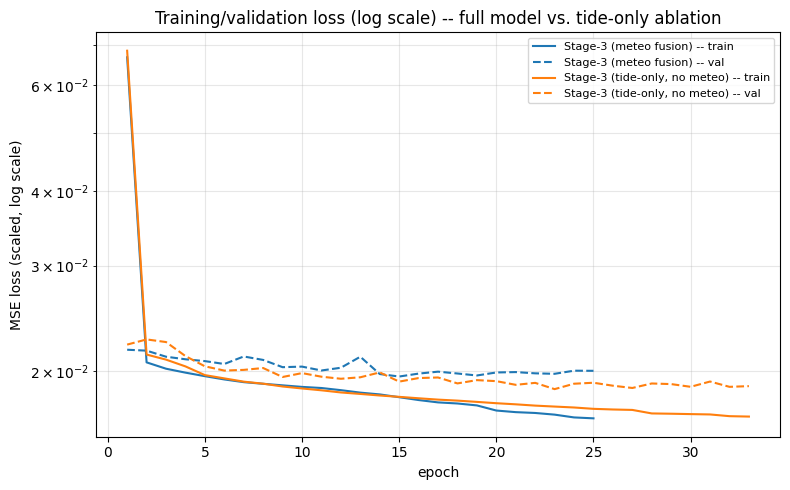

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_loss_curve.png


In [ ]:
plt.figure(figsize=(8, 5))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for color, (name, history) in zip(colors, [
    ('Stage-3 (meteo fusion)', stage3_history),
    ('Stage-3 (tide-only, no meteo)', stage3_tideonly_history),
]):
    epochs_arr = np.arange(1, len(history['train_loss']) + 1)
    plt.plot(epochs_arr, history['train_loss'], label=f'{name} -- train', color=color, linestyle='-')
    plt.plot(epochs_arr, history['val_loss'], label=f'{name} -- val', color=color, linestyle='--')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE loss (scaled, log scale)')
plt.title('Training/validation loss (log scale) -- full model vs. tide-only ablation')
plt.legend(fontsize=8)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
loss_curve_path = os.path.join(OUTPUT_DIR, 'stage3_loss_curve.png')
plt.savefig(loss_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"saved {loss_curve_path}")


## 10. Evaluation (test set, touched once)

This is the notebook's central result -- everything else either feeds into
it or checks a piece of it. RMSE/MAE per horizon, **three comparators**:
UTide standalone (the project's own harmonic-tide benchmark throughout),
Stage-3 (meteo fusion), and the tide-only ablation from s.8e. The
**headline 7** table below is directly comparable to stage 2's own
reported numbers; the full 30-horizon curve covers days through ~1 month
(not years -- see s.14's closing note for why that's out of scope here).

Every table below carries an **"Observed (mean, m)" reference row** --
the actual water level's own scale at that horizon, over the same masked
test samples the RMSE/MAE above it are computed from -- so an RMSE number
has something concrete to sit next to rather than floating with no scale.
No plot in this notebook puts calendar time on an axis; every chart here is
either error-vs-forecast-distance (a performance metric, aggregated over
the whole test set) or an attribution chart (SHAP, s.13).


In [ ]:
def observed_stats(y_raw, flagged):
    # same masking discipline as masked_rmse_mae, but reporting the observed value's own
    # scale (mean, std) per horizon rather than an error -- the context these tables need.
    means, stds = [], []
    for j in range(y_raw.shape[1]):
        mask = ~flagged[:, j]
        means.append(float(np.mean(y_raw[mask, j])))
        stds.append(float(np.std(y_raw[mask, j])))
    return np.array(means), np.array(stds)


rmse_utide, mae_utide = masked_rmse_mae(Ydec_targets_test, Y_test, Flag_test)
rmse_s3, mae_s3, test_preds_s3 = compute_metrics(stage3_model, predict_stage3, test_tensors, Y_test, Flag_test)
rmse_s3_tideonly, mae_s3_tideonly, test_preds_s3_tideonly = compute_metrics(
    stage3_tideonly_model, predict_stage3_tideonly, test_tensors_tideonly, Y_test, Flag_test)
obs_mean_test, obs_std_test = observed_stats(Y_test, Flag_test)

results = []
for j, hname in enumerate(HORIZON_NAMES):
    results.append({'model': 'UTide standalone', 'horizon': hname, 'rmse_m': rmse_utide[j], 'mae_m': mae_utide[j]})
    results.append({'model': 'Stage-3 (meteo fusion)', 'horizon': hname, 'rmse_m': rmse_s3[j], 'mae_m': mae_s3[j]})
    results.append({'model': 'Stage-3 (tide-only, no meteo)', 'horizon': hname,
                     'rmse_m': rmse_s3_tideonly[j], 'mae_m': mae_s3_tideonly[j]})

metrics_df = pd.DataFrame(results)
metrics_path = os.path.join(OUTPUT_DIR, 'stage3_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f"saved {metrics_path}")


def with_observed_row(pivot_table, horizon_names, stat=obs_mean_test):
    # prepend the observed-level reference row to any (model x horizon) pivot table
    idx = [HORIZON_NAMES.index(h) for h in horizon_names]
    obs_row = pd.DataFrame([stat[idx]], index=['Observed (mean, m)'], columns=horizon_names)
    return pd.concat([obs_row, pivot_table])


saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_metrics.csv


In [ ]:
print("RMSE (m), headline 7 horizons -- directly comparable to stage 2's own table:")
headline_rmse = metrics_df[metrics_df.horizon.isin(HEADLINE_NAMES)].pivot(index='model', columns='horizon', values='rmse_m')[HEADLINE_NAMES]
with_observed_row(headline_rmse, HEADLINE_NAMES).round(4)


RMSE (m), headline 7 horizons -- directly comparable to stage 2's own table:


,10min,1h,6h,24h,48h,72h,168h
"Observed (mean, m)",0.2528,0.2524,0.2527,0.2532,0.2539,0.2538,0.2528
Stage-3 (meteo fusion),0.0684,0.1018,0.2039,0.2326,0.2433,0.2453,0.2438
"Stage-3 (tide-only, no meteo)",0.0423,0.0731,0.1933,0.2246,0.2235,0.2272,0.2261
UTide standalone,0.2445,0.2445,0.2446,0.2444,0.2439,0.2438,0.2434


In [ ]:
print("MAE (m), headline 7 horizons:")
headline_mae = metrics_df[metrics_df.horizon.isin(HEADLINE_NAMES)].pivot(index='model', columns='horizon', values='mae_m')[HEADLINE_NAMES]
with_observed_row(headline_mae, HEADLINE_NAMES).round(4)


MAE (m), headline 7 horizons:


,10min,1h,6h,24h,48h,72h,168h
"Observed (mean, m)",0.2528,0.2524,0.2527,0.2532,0.2539,0.2538,0.2528
Stage-3 (meteo fusion),0.0519,0.0790,0.1534,0.1670,0.1761,0.1783,0.1769
"Stage-3 (tide-only, no meteo)",0.0339,0.0560,0.1388,0.1546,0.1565,0.1591,0.1583
UTide standalone,0.1754,0.1754,0.1755,0.1754,0.1752,0.1751,0.1749


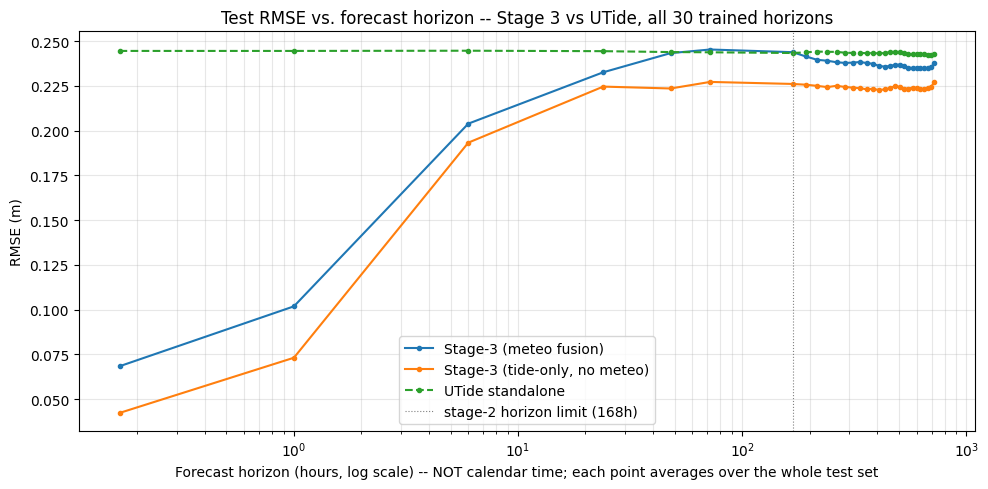

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_rmse_vs_horizon_full.png

For scale: observed water level over the test set ranges roughly -1.32m to 1.83m ODN (mean +/- 1 std across horizons).
   10min: full model vs. tide-only RMSE: -61.7% (positive = adding meteo/river helped)
      1h: full model vs. tide-only RMSE: -39.3% (positive = adding meteo/river helped)
      6h: full model vs. tide-only RMSE: -5.5% (positive = adding meteo/river helped)
     24h: full model vs. tide-only RMSE: -3.6% (positive = adding meteo/river helped)
     48h: full model vs. tide-only RMSE: -8.8% (positive = adding meteo/river helped)
     72h: full model vs. tide-only RMSE: -8.0% (positive = adding meteo/river helped)
    168h: full model vs. tide-only RMSE: -7.8% (positive = adding meteo/river helped)


In [ ]:
horizon_hours = np.array(HORIZON_STEPS) / 6.0  # steps are 10-min -> hours
rmse_pivot = metrics_df.pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES]

plt.figure(figsize=(10, 5))
for name in rmse_pivot.index:
    style = '--' if 'UTide' in name else '-'
    plt.plot(horizon_hours, rmse_pivot.loc[name], marker='o', markersize=3, linestyle=style, label=name)
plt.axvline(168, color='grey', linewidth=0.8, linestyle=':', label='stage-2 horizon limit (168h)')
plt.xscale('log')
plt.xlabel('Forecast horizon (hours, log scale) -- NOT calendar time; each point averages over the whole test set')
plt.ylabel('RMSE (m)')
plt.title('Test RMSE vs. forecast horizon -- Stage 3 vs UTide, all 30 trained horizons')
plt.legend()
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
rmse_curve_path = os.path.join(OUTPUT_DIR, 'stage3_rmse_vs_horizon_full.png')
plt.savefig(rmse_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"saved {rmse_curve_path}")

print(f"\nFor scale: observed water level over the test set ranges roughly "
      f"{obs_mean_test.min() - obs_std_test.max():.2f}m to {obs_mean_test.max() + obs_std_test.max():.2f}m ODN "
      f"(mean +/- 1 std across horizons).")

# positive = full model's RMSE is lower than tide-only's -> meteo/river helped at that horizon
meteo_improvement_pct = 100 * (rmse_s3_tideonly - rmse_s3) / rmse_s3_tideonly
for h, pct in zip(HEADLINE_NAMES, meteo_improvement_pct[:len(HEADLINE_NAMES)]):
    print(f"  {h:>6s}: full model vs. tide-only RMSE: {pct:+.1f}% (positive = adding meteo/river helped)")


## 11. Save outputs to Google Drive

Both models' weights are saved here, right after training/evaluation and
*before* the training-data ablation (s.12) and SHAP (s.13) -- both of those
are analyses layered on top of an already-finished model, not dependencies
of anything before this point, so they're placed last: if either hits an
issue, the two trained models, their evaluation, and both checkpoints have
already run and saved by the time it's reached.


In [ ]:
checkpoint_path = os.path.join(OUTPUT_DIR, 'stage3_tidal_seq2seq_multi.pt')
torch.save({
    'model_state_dict': stage3_model.state_dict(),
    'config': {
        'enc_hidden_size': ENC_HIDDEN_SIZE, 'enc_num_layers': ENC_NUM_LAYERS,
        'meteo_hidden_size': METEO_HIDDEN_SIZE, 'meteo_lookback_hours': METEO_LOOKBACK_HOURS,
        'river_hidden_size': RIVER_HIDDEN_SIZE, 'river_lookback_days': RIVER_LOOKBACK_DAYS,
        'dec_hidden_size': DEC_HIDDEN_SIZE, 'dec_num_layers': DEC_NUM_LAYERS,
        'attn_dims': (ATTN_DIM_TIDE, ATTN_DIM_METEO, ATTN_DIM_RIVER),
        'lookback': LOOKBACK, 'horizons': HORIZONS, 'decoder_seq_steps': DECODER_SEQ_STEPS,
        'target_slice_in_decoder': [TARGET_SLICE_IN_DECODER.start, TARGET_SLICE_IN_DECODER.stop],
        'lr': LR_MULTI, 'weight_decay': WD_MULTI, 'batch_size': BATCH_MULTI,  # winner of s.9a's search
    },
    'scalers': {
        'tide_utide': {'mean': train_mean, 'std': train_std},
        'pressure': {'mean': pressure_mean, 'std': pressure_std},
        'u10': {'mean': u10_mean, 'std': u10_std},
        'v10': {'mean': v10_mean, 'std': v10_std},
        'rainfall': {'mean': rain_mean, 'std': rain_std},
        'discharge': {'mean': disc_mean, 'std': disc_std},
    },
}, checkpoint_path)
print(f"saved {checkpoint_path}")

tideonly_checkpoint_path = os.path.join(OUTPUT_DIR, 'stage3_tidal_seq2seq_tideonly.pt')
torch.save({
    'model_state_dict': stage3_tideonly_model.state_dict(),
    'config': {
        'enc_hidden_size': ENC_HIDDEN_SIZE, 'enc_num_layers': ENC_NUM_LAYERS,
        'dec_hidden_size': DEC_HIDDEN_SIZE, 'dec_num_layers': DEC_NUM_LAYERS,
        'attn_dim': ATTN_DIM_TIDE,
        'lookback': LOOKBACK, 'horizons': HORIZONS, 'decoder_seq_steps': DECODER_SEQ_STEPS,
        'target_slice_in_decoder': [TARGET_SLICE_IN_DECODER.start, TARGET_SLICE_IN_DECODER.stop],
        'lr': LR_TIDEONLY, 'weight_decay': WD_TIDEONLY, 'batch_size': BATCH_TIDEONLY,  # s.9a winner
    },
    'scalers': {'tide_utide': {'mean': train_mean, 'std': train_std}},
}, tideonly_checkpoint_path)
print(f"saved {tideonly_checkpoint_path}")

print(f"\nAll stage-3 outputs (so far) are under: {OUTPUT_DIR}")
import glob
for p in sorted(glob.glob(os.path.join(OUTPUT_DIR, '*'))):
    print(f"  {os.path.basename(p)}")


saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_tidal_seq2seq_multi.pt
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_tidal_seq2seq_tideonly.pt

All stage-3 outputs (so far) are under: /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs
  stage3_loss_curve.png
  stage3_lr_search_multi.csv
  stage3_lr_search_tideonly.csv
  stage3_metrics.csv
  stage3_rmse_vs_horizon_full.png
  stage3_tidal_seq2seq_multi.pt
  stage3_tidal_seq2seq_tideonly.pt


## 12. Training-data-volume ablation

Answers the fourth research question directly: **how does the amount of
training data available affect accuracy?** Mirrors stage 2 section 14.3
exactly -- train end fixed at 2018-01-01, validation/test exactly as in
s.5/s.10 (2018-2020 / 2021-2024); only the *start* of the training window
moves: 2015 (3yr), 2011 (7yr), 2008 (10yr), vs. the full 2004-2018 (14yr)
used everywhere else. **UTide is refit separately for each window** --
with less history its own constituent estimates degrade too, so tracking
a UTide-only comparator alongside the retrained model separates "the
network has less to learn from" from "the tidal input it's given is
itself worse," the same distinction stage 2 drew.

Every train-derived statistic is refit per scenario -- the tide/UTide
scaler and the meteo scalers, same as the network itself is retrained.
**Hyperparameters are the opposite: held fixed**, at whatever s.9a's
random search found best for the full 14-year model, across every reduced
window here. That's intentional, and the mirror image of s.8e/s.9's
choice to tune the tide-only ablation independently -- there, architecture
was the one thing allowed to vary, so hyperparameters had to be free to
adapt to each. Here, training-data volume is the one thing meant to vary;
re-searching hyperparameters per scenario would confound "less data" with
"different optimization," exactly the ambiguity this ablation exists to
rule out.

**A second, unrelated simplification**: the rainfall/discharge climatology
fill (s.3) stays fixed to the full-history version rather than being
re-derived per window. The river branch already shows the weakest signal
of anything in this model (s.10's ablation, s.13's SHAP), so re-deriving
a monthly climatology three more times was judged not worth the added
code complexity for an expected negligible effect -- a scope choice,
stated here rather than left implicit.

Only the full (meteo-fusion) model is retrained here, matching stage 2's
own scope (it tested reduced data on its one main model, not every
baseline). This trains 3 more full models on top of the 2 already in this
notebook -- the most expensive section here, same as stage 2 flags its
own section 14.


In [ ]:
REDUCED_TRAIN_STARTS = {'3yr': '2015-01-01', '7yr': '2011-01-01', '10yr': '2008-01-01'}


def refit_utide_recon_ext(train_start, train_end):
    # same fit discipline as s.4, restricted to [train_start, train_end); reconstructed over
    # the same extended range so the padded decoder sequence (s.6/s.8c) stays computable.
    mask = (df['DateTime'] >= train_start) & (df['DateTime'] < train_end)
    fit_series = df.loc[mask, 'Observed_ODN'].copy()
    fit_series[df.loc[mask, 'is_flagged']] = np.nan
    coef_r = utide.solve(df.loc[mask, 'DateTime'], fit_series, lat=SITE_LAT, method='ols', conf_int='none')
    recon_r = utide.reconstruct(utide_index, coef_r, min_SNR=0, min_PE=0, verbose=False)
    return np.asarray(recon_r['h'], dtype=np.float32)


def prepare_reduced_scenario(name, train_start):
    recon_r = refit_utide_recon_ext(train_start, TRAIN_END)
    tr_df_r = df[(df['DateTime'] >= train_start) & (df['DateTime'] < TRAIN_END)].reset_index(drop=True)

    # val/test windows are rebuilt (not reused) because the decoder's UTide input -- and the
    # UTide-standalone comparator -- must reflect what a model trained only on this window
    # would actually have seen; only Y (the real observed target) is unaffected by the refit.
    Xtr, Xmtr, Xrtr, Ydtr, Ytr, Ftr, Ttr, Atr = build_windows_stage3(
        tr_df_r, LOOKBACK, HORIZON_STEPS, utide_full=recon_r, utide_start=UTIDE_START)
    Xva, Xmva, Xrva, Ydva, Yva, Fva, Tva, Ava = build_windows_stage3(
        val_df, LOOKBACK, HORIZON_STEPS, utide_full=recon_r, utide_start=UTIDE_START)
    Xte, Xmte, Xrte, Ydte, Yte, Fte, Tte, Ate = build_windows_stage3(
        test_df, LOOKBACK, HORIZON_STEPS, utide_full=recon_r, utide_start=UTIDE_START)

    Xtr, Xmtr, Xrtr, Ydtr, Ytr, Ftr = (Xtr[::TRAIN_STRIDE], Xmtr[::TRAIN_STRIDE], Xrtr[::TRAIN_STRIDE],
                                        Ydtr[::TRAIN_STRIDE], Ytr[::TRAIN_STRIDE], Ftr[::TRAIN_STRIDE])

    mean_, std_ = float(tr_df_r['Observed_ODN'].mean()), float(tr_df_r['Observed_ODN'].std())
    p_mean_, p_std_ = float(Xmtr[..., 0].mean()), float(Xmtr[..., 0].std())
    u_mean_, u_std_ = float(Xmtr[..., 1].mean()), float(Xmtr[..., 1].std())
    v_mean_, v_std_ = float(Xmtr[..., 2].mean()), float(Xmtr[..., 2].std())
    r_mean_, r_std_ = float(Xrtr[..., 0].mean()), float(Xrtr[..., 0].std())
    d_mean_, d_std_ = float(Xrtr[..., 1].mean()), float(Xrtr[..., 1].std())

    def sc_tide(a):
        return (a - mean_) / std_

    def sc_meteo(xm):
        out = xm.copy()
        out[..., 0] = (out[..., 0] - p_mean_) / p_std_
        out[..., 1] = (out[..., 1] - u_mean_) / u_std_
        out[..., 2] = (out[..., 2] - v_mean_) / v_std_
        return out

    def sc_river(xr):
        out = xr.copy()
        out[..., 0] = (out[..., 0] - r_mean_) / r_std_
        out[..., 1] = (out[..., 1] - d_mean_) / d_std_
        return out

    train_tensors_r = {'X': to_tensor(sc_tide(Xtr)), 'Xm': to_tensor(sc_meteo(Xmtr)), 'Xr': to_tensor(sc_river(Xrtr)),
                        'Ydec': to_tensor(sc_tide(Ydtr)), 'Y': to_tensor(sc_tide(Ytr)), 'Flag': to_tensor(Ftr, dtype=torch.bool)}
    val_tensors_r = {'X': to_tensor(sc_tide(Xva)), 'Xm': to_tensor(sc_meteo(Xmva)), 'Xr': to_tensor(sc_river(Xrva)),
                      'Ydec': to_tensor(sc_tide(Ydva)), 'Y': to_tensor(sc_tide(Yva)), 'Flag': to_tensor(Fva, dtype=torch.bool)}
    test_tensors_r = {'X': to_tensor(sc_tide(Xte)), 'Xm': to_tensor(sc_meteo(Xmte)), 'Xr': to_tensor(sc_river(Xrte)),
                       'Ydec': to_tensor(sc_tide(Ydte))}

    print(f"[{name}] train {tr_df_r.DateTime.min().date()} -> {tr_df_r.DateTime.max().date()} "
          f"({Xtr.shape[0]:,} windows, stride {TRAIN_STRIDE})  val {Xva.shape[0]:,}  test {Xte.shape[0]:,}")

    return {
        'name': name, 'mean': mean_, 'std': std_,
        'train_tensors': train_tensors_r, 'val_tensors': val_tensors_r, 'test_tensors': test_tensors_r,
        'Y_test': Yte, 'Flag_test': Fte, 'Ydec_test': Ydte[:, TARGET_SLICE_IN_DECODER],
    }


@torch.no_grad()
def compute_metrics_scaled(model, predict_fn, tensors, y_raw, flagged, mean_, std_, batch_size=4096):
    # same as compute_metrics, but takes the scaler explicitly -- each reduced scenario has
    # its own mean/std, fit only on the data that scenario was allowed to see.
    model.eval()
    preds = []
    n = tensors['X'].shape[0]
    for start in range(0, n, batch_size):
        batch = {k: v[start:start + batch_size] for k, v in tensors.items() if k not in ('Y', 'Flag')}
        preds.append(predict_fn(model, batch))
    preds_m = torch.cat(preds).cpu().numpy() * std_ + mean_
    rmse, mae = masked_rmse_mae(preds_m, y_raw, flagged)
    return rmse, mae


In [ ]:
reduced_results = [
    {'model': '14yr (full)', 'horizon': h, 'rmse_m': rmse_s3[j], 'mae_m': mae_s3[j], 'train_years': 14}
    for j, h in enumerate(HORIZON_NAMES)
]
reduced_utide_only = [
    {'model': '14yr (full)', 'horizon': h, 'rmse_m': rmse_utide[j], 'mae_m': mae_utide[j], 'train_years': 14}
    for j, h in enumerate(HORIZON_NAMES)
]

for name, start in REDUCED_TRAIN_STARTS.items():
    n_years = int(name.replace('yr', ''))
    scen = prepare_reduced_scenario(name, start)

    rmse_u, mae_u = masked_rmse_mae(scen['Ydec_test'], scen['Y_test'], scen['Flag_test'])
    reduced_utide_only += [
        {'model': name, 'horizon': h, 'rmse_m': rmse_u[j], 'mae_m': mae_u[j], 'train_years': n_years}
        for j, h in enumerate(HORIZON_NAMES)
    ]

    set_seed()
    m = TidalSeq2SeqMulti().to(device)
    m, _ = train_model(
        m, predict_stage3, scen['train_tensors'], scen['val_tensors'],
        epochs=EPOCHS, batch_size=BATCH_MULTI, lr=LR_MULTI, patience=PATIENCE,
        weight_decay=WD_MULTI, label=f'stage3-{name}',  # held fixed at s.9a's winner -- see markdown above
    )

    rmse_r, mae_r = compute_metrics_scaled(
        m, predict_stage3, scen['test_tensors'], scen['Y_test'], scen['Flag_test'], scen['mean'], scen['std'])
    reduced_results += [
        {'model': name, 'horizon': h, 'rmse_m': rmse_r[j], 'mae_m': mae_r[j], 'train_years': n_years}
        for j, h in enumerate(HORIZON_NAMES)
    ]

reduced_df = pd.DataFrame(reduced_results)
reduced_metrics_path = os.path.join(OUTPUT_DIR, 'stage3_reduced_training_data_metrics.csv')
reduced_df.to_csv(reduced_metrics_path, index=False)
print(f"saved {reduced_metrics_path}")

utide_only_df = pd.DataFrame(reduced_utide_only)
utide_only_metrics_path = os.path.join(OUTPUT_DIR, 'stage3_reduced_training_utide_only_metrics.csv')
utide_only_df.to_csv(utide_only_metrics_path, index=False)
print(f"saved {utide_only_metrics_path}")

train_years_order = reduced_df.drop_duplicates('model').set_index('model')['train_years'].sort_values()
reduced_pivot = reduced_df.pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES].loc[train_years_order.index]


solve: matrix prep ... solution ... done.
[3yr] train 2015-01-01 -> 2017-12-31 (44,119 windows, stride 3)  val 153,409  test 169,821
[stage3-3yr] epoch 001  train_loss=0.19652  val_loss=0.03224  lr=1.8e-03  *
[stage3-3yr] epoch 002  train_loss=0.02525  val_loss=0.02745  lr=1.8e-03  *
[stage3-3yr] epoch 003  train_loss=0.02025  val_loss=0.02230  lr=1.8e-03  *
[stage3-3yr] epoch 004  train_loss=0.01959  val_loss=0.02305  lr=1.8e-03
[stage3-3yr] epoch 005  train_loss=0.01914  val_loss=0.02215  lr=1.8e-03  *
[stage3-3yr] epoch 006  train_loss=0.01907  val_loss=0.02217  lr=1.8e-03
[stage3-3yr] epoch 007  train_loss=0.01899  val_loss=0.02249  lr=1.8e-03
[stage3-3yr] epoch 008  train_loss=0.01893  val_loss=0.02157  lr=1.8e-03  *
[stage3-3yr] epoch 009  train_loss=0.01876  val_loss=0.02162  lr=1.8e-03
[stage3-3yr] epoch 010  train_loss=0.01872  val_loss=0.02161  lr=1.8e-03
[stage3-3yr] epoch 011  train_loss=0.01866  val_loss=0.02157  lr=1.8e-03  *
[stage3-3yr] epoch 012  train_loss=0.01854  va

In [ ]:
print("RMSE (m) by training-data window, headline 7 horizons:")
with_observed_row(reduced_pivot[HEADLINE_NAMES], HEADLINE_NAMES).round(4)


RMSE (m) by training-data window, headline 7 horizons:


,10min,1h,6h,24h,48h,72h,168h
"Observed (mean, m)",0.2528,0.2524,0.2527,0.2532,0.2539,0.2538,0.2528
3yr,0.1056,0.1351,0.2196,0.2435,0.2512,0.2500,0.2489
7yr,0.0649,0.1078,0.2154,0.2405,0.2480,0.2495,0.2491
10yr,0.0847,0.1232,0.2212,0.2416,0.2473,0.2453,0.2454
14yr (full),0.0684,0.1018,0.2039,0.2326,0.2433,0.2453,0.2438


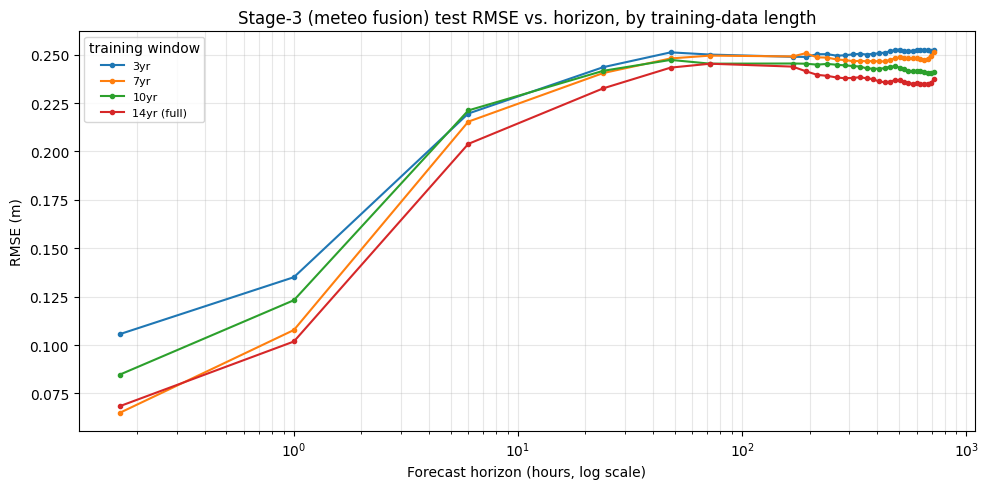

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_reduced_training_rmse_vs_horizon.png


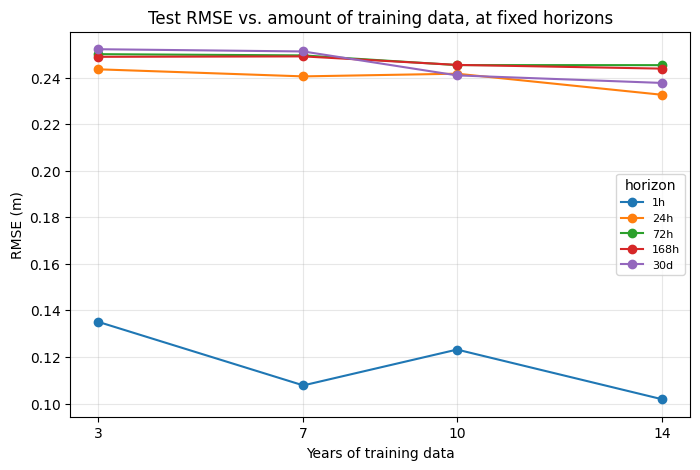

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_rmse_vs_training_years.png


In [ ]:
plt.figure(figsize=(10, 5))
for name in reduced_pivot.index:
    plt.plot(horizon_hours, reduced_pivot.loc[name], marker='o', markersize=3, label=name)
plt.xscale('log')
plt.xlabel('Forecast horizon (hours, log scale)')
plt.ylabel('RMSE (m)')
plt.title('Stage-3 (meteo fusion) test RMSE vs. horizon, by training-data length')
plt.legend(title='training window', fontsize=8)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
reduced_plot_path = os.path.join(OUTPUT_DIR, 'stage3_reduced_training_rmse_vs_horizon.png')
plt.savefig(reduced_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"saved {reduced_plot_path}")

fixed_horizons_check = [h for h in ['1h', '24h', '72h', '168h', '30d'] if h in HORIZON_NAMES]
plt.figure(figsize=(8, 5))
for hname in fixed_horizons_check:
    ys = [reduced_pivot.loc[name, hname] for name in train_years_order.index]
    plt.plot(train_years_order.values, ys, marker='o', label=hname)
plt.xlabel('Years of training data')
plt.ylabel('RMSE (m)')
plt.title('Test RMSE vs. amount of training data, at fixed horizons')
plt.legend(title='horizon', fontsize=8)
plt.grid(alpha=0.3)
plt.xticks(sorted(train_years_order.unique()))
data_cliff_plot_path = os.path.join(OUTPUT_DIR, 'stage3_rmse_vs_training_years.png')
plt.savefig(data_cliff_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"saved {data_cliff_plot_path}")


## 13. Interpretability: SHAP

Which branch/variable actually drives each horizon's prediction on the
**full** (meteo-fusion) model -- for its own sake, and as a check against
the EDA's own correlation findings (does the trained model lean on `v10`
more than rainfall, the way `EDA/meteo_eda.ipynb` predicted?) and against
s.10's ablation result (does whatever the tide-only comparison found also
show up here, branch by branch?).

**Method**: `shap.GradientExplainer`, not `KernelExplainer` -- with hundreds
of raw scalar inputs across four branches once flattened, kernel SHAP would
need far too many model evaluations to be practical; GradientExplainer uses
backprop directly and natively supports multi-input PyTorch models (a list
of tensors in, a list of per-input attribution arrays out). A background
sample of real training windows anchors the explanation; a separate sample
of test windows is what gets explained.

Runs over a **representative subset** of horizons (10min, 6h, 24h, 168h,
14d, 30d) rather than all 30, to keep runtime reasonable -- widen
`SHAP_HORIZONS` below if there's time on Colab.

Raw per-scalar SHAP values (96 tide steps + 360 meteo values + 120 river
values + 34 decoder-sequence steps, *per horizon*) are too granular to read
directly, so they're summed into **branch/variable-level contributions**
below.

**Caveat, stated plainly rather than glossed over**: SHAP on correlated,
autocorrelated time-series inputs (adjacent tide/pressure readings move
together) can split or share credit between them in ways that don't map
cleanly onto physical intuition -- read this as *relative importance under
this specific attribution scheme*, not literal causal ground truth.

**A GPU-specific wrinkle, fixed properly here.** cuDNN's fused RNN kernel
only keeps the state its backward pass needs when the forward call runs in
training mode -- so `GradientExplainer`'s `.backward()` through the LSTMs
raises `RuntimeError: cudnn RNN backward can only be called in training
mode` on a `.eval()`-mode model. This is a known, documented cuDNN
limitation (not a bug in this notebook or in SHAP), and the earlier version
of this cell worked around it by flipping the whole model into `.train()`
mode for the SHAP loop -- which only stays safe because this architecture
has no Dropout/BatchNorm anywhere. The fix below is more surgical and
doesn't lean on that: it keeps the model in genuine `.eval()` mode
(semantically correct -- SHAP is explaining a trained model, not training
one) and instead disables cuDNN's fused RNN kernel for just this block via
`torch.backends.cudnn.flags(enabled=False)`. That routes PyTorch to its
generic (non-cuDNN) RNN backward implementation, which was never subject to
the training-mode restriction in the first place -- so it doesn't depend on
the model staying Dropout/BatchNorm-free, and stays correct even if the
architecture changes later. The only cost is a slower, non-fused RNN kernel
for this section alone, which is already scoped to a subset of horizons/
samples to keep runtime reasonable. **Not verified against a real GPU
locally** (no CUDA available in this environment) -- this is the standard
documented fix for this exact cuDNN restriction, but it's worth confirming
it clears cleanly on the actual Colab run.

Placed last deliberately: everything else in this notebook (both trained
models, their evaluation, both checkpoints, the training-data ablation)
has already run and saved by the time this cell executes, so a problem
here doesn't cost the rest of the run.


In [ ]:
class HorizonWrapper(nn.Module):
    # SHAP explains one fixed-size output per call; this selects a single horizon
    # out of the model's (B, 30) prediction so GradientExplainer sees a (B, 1) output.
    def __init__(self, base_model, horizon_idx):
        super().__init__()
        self.base_model = base_model
        self.horizon_idx = horizon_idx

    def forward(self, x_tide, x_meteo, x_river, x_utide):
        preds, _ = self.base_model(x_tide, x_meteo, x_river, x_utide)
        return preds[:, self.horizon_idx:self.horizon_idx + 1]


SHAP_HORIZONS = ['10min', '6h', '24h', '168h', '14d', '30d']
SHAP_BACKGROUND_N = 150
SHAP_EXPLAIN_N = 300

set_seed()
bg_idx = np.random.choice(X_train_t.shape[0], size=SHAP_BACKGROUND_N, replace=False)
explain_idx = np.random.choice(X_test_t.shape[0], size=SHAP_EXPLAIN_N, replace=False)

shap_background = [X_train_t[bg_idx], Xm_train_t[bg_idx], Xr_train_t[bg_idx], Ydec_train_t[bg_idx]]
shap_explain_inputs = [X_test_t[explain_idx], Xm_test_t[explain_idx], Xr_test_t[explain_idx], Ydec_test_t[explain_idx]]

# cuDNN's fused RNN kernel only retains backward-pass state when the forward call runs in
# training mode, so GradientExplainer's backward() through the LSTMs fails on a .eval()-mode
# model (see the markdown above for the full explanation). Keeping the model in genuine
# eval() mode -- correct, since SHAP is explaining a trained model, not training one -- and
# disabling cuDNN's fused kernel just for this block routes PyTorch to the generic RNN
# backward implementation instead, which has no such restriction.
stage3_model.eval()
shap_rows = []
tide_lookback_importance = {}
with torch.backends.cudnn.flags(enabled=False):
    for hname in SHAP_HORIZONS:
        j = HORIZON_NAMES.index(hname)
        wrapped = HorizonWrapper(stage3_model, horizon_idx=j)
        explainer = shap.GradientExplainer(wrapped, shap_background)
        sv_tide, sv_meteo, sv_river, sv_utide = explainer.shap_values(shap_explain_inputs)
        sv_tide, sv_meteo, sv_river, sv_utide = [np.abs(s).squeeze(-1) for s in (sv_tide, sv_meteo, sv_river, sv_utide)]

        shap_rows.append({
            'horizon': hname,
            'tide_history': sv_tide.sum(axis=1).mean(),
            'pressure': sv_meteo[..., 0].sum(axis=1).mean(),
            'wind_u10': sv_meteo[..., 1].sum(axis=1).mean(),
            'wind_v10': sv_meteo[..., 2].sum(axis=1).mean(),
            'rainfall': sv_river[..., 0].sum(axis=1).mean(),
            'discharge': sv_river[..., 1].sum(axis=1).mean(),
            'river_availability_flags': sv_river[..., 2:4].sum(axis=(1, 2)).mean(),
            'utide_decoder': sv_utide.sum(axis=1).mean(),
        })
        tide_lookback_importance[hname] = sv_tide.mean(axis=0)  # (96,)
        print(f"SHAP done for horizon {hname}")

shap_df = pd.DataFrame(shap_rows).set_index('horizon').loc[SHAP_HORIZONS]
shap_summary_path = os.path.join(OUTPUT_DIR, 'stage3_shap_branch_contributions.csv')
shap_df.to_csv(shap_summary_path)
print(f"saved {shap_summary_path}")
shap_df.round(4)


SHAP done for horizon 10min
SHAP done for horizon 6h
SHAP done for horizon 24h
SHAP done for horizon 168h
SHAP done for horizon 14d
SHAP done for horizon 30d
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_shap_branch_contributions.csv


,tide_history,pressure,wind_u10,wind_v10,rainfall,discharge,river_availability_flags,utide_decoder
horizon,,,,,,,,
10min,1.3895,0.0195,0.0191,0.0216,0.0232,0.0247,0.0082,0.9809
6h,0.4666,0.0620,0.0459,0.0812,0.0303,0.0266,0.0081,1.0868
24h,0.1405,0.0714,0.0318,0.0437,0.0361,0.0296,0.0088,1.0102
168h,0.1025,0.0200,0.0154,0.0172,0.0324,0.0312,0.0070,0.9471
14d,0.0828,0.0131,0.0110,0.0091,0.0342,0.0366,0.0072,1.0615
30d,0.1076,0.0145,0.0155,0.0140,0.0344,0.0406,0.0078,1.0876


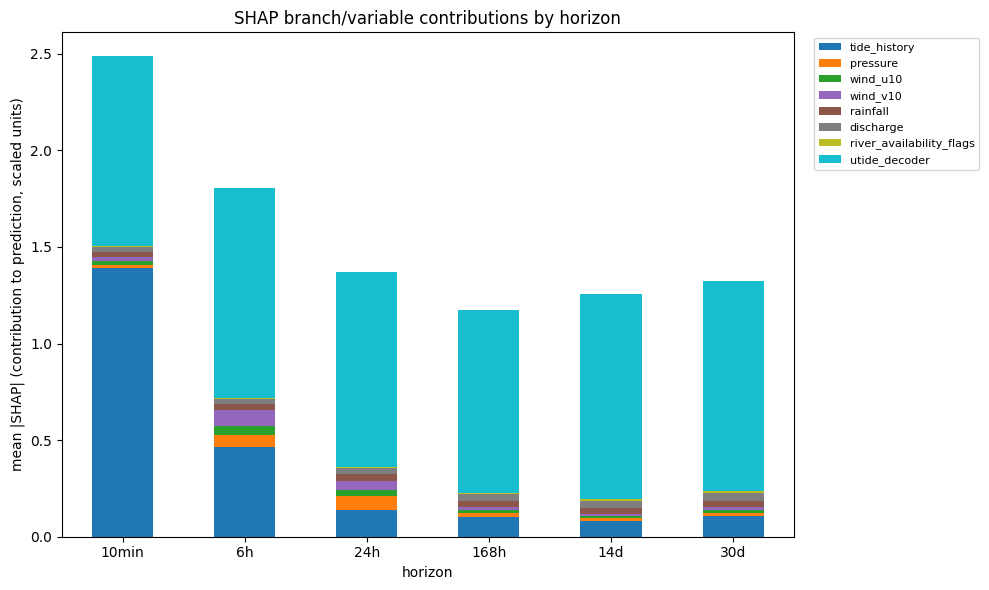

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_shap_branch_contributions.png


In [ ]:
ax = shap_df.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')
ax.set_ylabel('mean |SHAP| (contribution to prediction, scaled units)')
ax.set_xlabel('horizon')
ax.set_title('SHAP branch/variable contributions by horizon')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
shap_bar_path = os.path.join(OUTPUT_DIR, 'stage3_shap_branch_contributions.png')
plt.savefig(shap_bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"saved {shap_bar_path}")


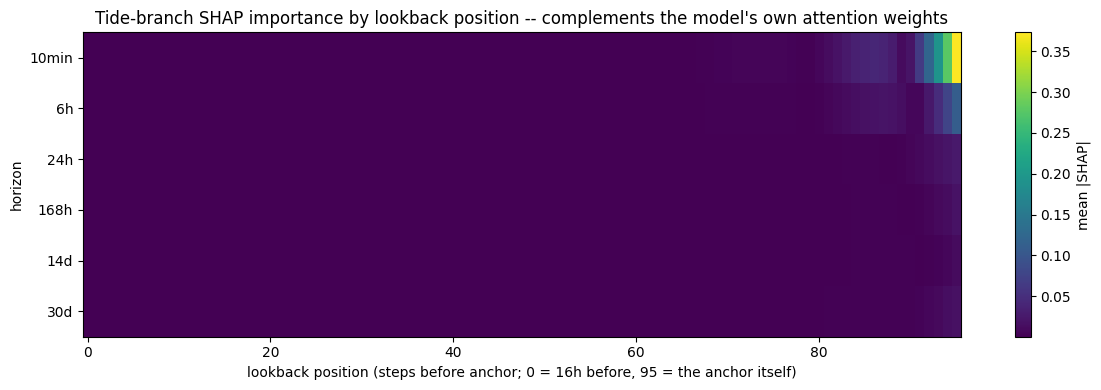

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_shap_tide_lookback_heatmap.png
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_shap_tide_lookback_importance.csv


In [ ]:
lookback_matrix = np.stack([tide_lookback_importance[h] for h in SHAP_HORIZONS])  # (n_shap_horizons, 96)

plt.figure(figsize=(12, 4))
plt.imshow(lookback_matrix, aspect='auto', cmap='viridis', interpolation='nearest')
plt.colorbar(label='mean |SHAP|')
plt.yticks(range(len(SHAP_HORIZONS)), SHAP_HORIZONS)
plt.xlabel('lookback position (steps before anchor; 0 = 16h before, 95 = the anchor itself)')
plt.ylabel('horizon')
plt.title('Tide-branch SHAP importance by lookback position -- complements the model\'s own attention weights')
plt.tight_layout()
heatmap_path = os.path.join(OUTPUT_DIR, 'stage3_shap_tide_lookback_heatmap.png')
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"saved {heatmap_path}")

shap_summary_path2 = os.path.join(OUTPUT_DIR, 'stage3_shap_tide_lookback_importance.csv')
pd.DataFrame(lookback_matrix, index=SHAP_HORIZONS).to_csv(shap_summary_path2)
print(f"saved {shap_summary_path2}")


## 14. Research questions -- summary of findings

Everything above answers one of four questions this stage was built around.
This section pulls the relevant numbers back together against each one, in
one place, rather than leaving the reader to reassemble them from six
sections of tables.

1. **How can ML improve traditional water level forecasting methods?**
   The headline comparison throughout: does Stage-3 beat UTide standalone,
   and by how much, across the forecast range this model was trained and
   evaluated on (10min to 30 days) -- s.10.
2. **How accurately do these models predict total water level relative to
   UTide?** The headline-7 and full-30 RMSE/MAE tables in s.10, each with
   an observed-water-level reference row for scale.
3. **How does relative performance change across forecast horizons (days,
   months, years)?** The full-30 RMSE-vs-horizon curve in s.10 covers days
   through ~1 month. Years are not attempted here -- see the note at the
   end of this section for why, stated plainly rather than left implicit.
4. **Does adding meteorological covariates improve accuracy?** The
   tide-only ablation (s.8e) vs. the full model -- each independently
   hyperparameter-tuned (s.9a) so neither is handicapped by the other's
   optimal settings, everything else (architecture family, data, seed) held
   fixed (s.10's `meteo_improvement_pct`), cross-checked against SHAP's
   branch-level attribution (s.13).
5. **How does available training data affect accuracy?** The
   reduced-training-window ablation (s.12), mirroring stage 2 section 14.3.


In [ ]:
print("=" * 70)
print("RQ 1-2: Stage-3 vs UTide, headline 7 horizons")
print("=" * 70)
headline_summary = metrics_df[metrics_df.horizon.isin(HEADLINE_NAMES)].pivot(
    index='model', columns='horizon', values='rmse_m')[HEADLINE_NAMES]
print(with_observed_row(headline_summary, HEADLINE_NAMES).round(4))

avg_utide = rmse_utide[:len(HEADLINE_NAMES)].mean()
avg_s3 = rmse_s3[:len(HEADLINE_NAMES)].mean()
avg_tideonly = rmse_s3_tideonly[:len(HEADLINE_NAMES)].mean()
print(f"\nMean RMSE across headline 7 horizons -- UTide: {avg_utide:.4f}m, "
      f"Stage-3 (meteo fusion): {avg_s3:.4f}m ({100*(avg_utide-avg_s3)/avg_utide:+.1f}% vs UTide), "
      f"Stage-3 (tide-only): {avg_tideonly:.4f}m ({100*(avg_utide-avg_tideonly)/avg_utide:+.1f}% vs UTide)")

print("\n" + "=" * 70)
print("RQ 3: how far the RMSE-vs-horizon curve reaches, and why not further")
print("=" * 70)
print(f"Trained/evaluated range: 10min to {HORIZON_NAMES[-1]} (30 days). Full curve: s.10's "
      f"'{os.path.basename(rmse_curve_path)}'.")
print("Years-ahead horizons were not added to this stage: a genuinely year-long trained "
      "horizon needs gap-free segments over a year long near the end of every split (a much "
      "harsher version of the constraint checked for 30 days in s.6), and stage2_architecture.md "
      "s.6.1's information-ceiling finding already predicts the learnable correction over UTide "
      "mostly vanishes well before 30 days -- so a year-ahead point would likely just show "
      "~UTide performance, at real data-availability cost, for a result the 30-day curve above "
      "already points to.")

print("\n" + "=" * 70)
print("RQ 4: does adding meteo/river data help? (tide-only ablation, s.8e/s.10)")
print("=" * 70)
for h, pct in zip(HEADLINE_NAMES, meteo_improvement_pct[:len(HEADLINE_NAMES)]):
    print(f"  {h:>6s}: {pct:+.1f}% RMSE change from adding meteo/river (positive = helped)")
print(f"See s.13 (SHAP) for which specific branch/variable drives this, per horizon.")

print("\n" + "=" * 70)
print("RQ 5: does more training data help? (s.12)")
print("=" * 70)
for hname in fixed_horizons_check:
    vals = ', '.join(f"{yr}yr={reduced_pivot.loc[name, hname]:.4f}m"
                      for name, yr in zip(train_years_order.index, train_years_order.values))
    print(f"  {hname:>6s}: {vals}")


RQ 1-2: Stage-3 vs UTide, headline 7 horizons
                                10min      1h      6h     24h     48h     72h  \
Observed (mean, m)             0.2528  0.2524  0.2527  0.2532  0.2539  0.2538   
Stage-3 (meteo fusion)         0.0684  0.1018  0.2039  0.2326  0.2433  0.2453   
Stage-3 (tide-only, no meteo)  0.0423  0.0731  0.1933  0.2246  0.2235  0.2272   
UTide standalone               0.2445  0.2445  0.2446  0.2444  0.2439  0.2438   

                                 168h  
Observed (mean, m)             0.2528  
Stage-3 (meteo fusion)         0.2438  
Stage-3 (tide-only, no meteo)  0.2261  
UTide standalone               0.2434  

Mean RMSE across headline 7 horizons -- UTide: 0.2442m, Stage-3 (meteo fusion): 0.1913m (+21.6% vs UTide), Stage-3 (tide-only): 0.1729m (+29.2% vs UTide)

RQ 3: how far the RMSE-vs-horizon curve reaches, and why not further
Trained/evaluated range: 10min to 30d (30 days). Full curve: s.10's 'stage3_rmse_vs_horizon_full.png'.
Years-ahead horizons